# Calibration: Depolar Model vs Experimental Raman (RamanBioLib)

This notebook adapts the `depolar_spectra_pipeline` workflow to compare model predictions against
experimental Raman spectra in `experimental_data/raman_spectra_db.csv`.

Name resolution strategy:
- Source experimental names from local RamanBioLib CSV/metadata.
- Resolve names using **PubChem PUG REST** (high-quality source).
- Build and persist a **local cache DB** (`artifacts/calibration_cache/component_structure_cache.json`) so lookups are reproducible/offline after first run.

Prediction strategy:
- Load your custom depolar checkpoint from `artifacts/spectra_queue/prodq-depolar-a100x8-20260219-044935`.
- Combine with `Hi`/`Hij` heads to recover normal modes/frequencies.
- Simulate Raman spectra via Lorentz broadening + intensity conversion.
- Compare to experimental spectra using RMSE, correlation, and discrete Fréchet distance.


In [1]:
from __future__ import annotations

import ast
import json
import math
import re
import sys
import time
import warnings
from pathlib import Path
from typing import Any, Dict, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import torch
from IPython.display import Image, display
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

warnings.filterwarnings(
    "ignore",
    message="The TorchScript type system doesn't support instance-level annotations",
)


/Users/rahul/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/8l/vgsnzp1s0g54ndf86zjdlwc00000gn/T/matplotlib-8c2agrg7 because there was an issue with the default path (/Users/rahul/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


In [2]:
# Resolve repo root and import project modules.
if (Path.cwd() / "ramanchembl_pipeline").exists():
    REPO_ROOT = Path.cwd()
else:
    REPO_ROOT = Path.cwd().parent

CAPSULE_CODE = REPO_ROOT / "capsule-3259363" / "code"

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(CAPSULE_CODE) not in sys.path:
    sys.path.insert(0, str(CAPSULE_CODE))

from train.train_detanet import build_model  # noqa: E402
from detanet_model.constant import atom_masses  # noqa: E402
from detanet_model.model_loader import Hi_model, Hij_model  # noqa: E402
from detanet_model.spectra_simulator import (  # noqa: E402
    Lorenz_broadening,
    chain_rule_raman,
    get_raman_act,
    get_raman_intensity,
    hessfreq,
)
from torch_geometric.nn import radius_graph  # noqa: E402

print("repo_root =", REPO_ROOT)
print("capsule   =", CAPSULE_CODE)


repo_root = /Users/rahul/Desktop/hp-proteins-ml
capsule   = /Users/rahul/Desktop/hp-proteins-ml/capsule-3259363/code


In [3]:
# Paths and runtime config
EXPERIMENTAL_CSV = REPO_ROOT / "ramanchembl_pipeline" / "experimental_data" / "raman_spectra_db.csv"
METADATA_CSV = REPO_ROOT / "ramanchembl_pipeline" / "experimental_data" / "metadata_db.csv"
METADATA_URL = "https://raw.githubusercontent.com/mteranm/ramanbiolib/main/ramanbiolib/db/metadata_db.csv"

# Depolar path must match depolar_spectra_pipeline.ipynb
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "spectra_queue" / "prodq-depolar-a100x8-20260219-044935"

# Candidate checkpoints (selected by compatibility, not just existence).
WEIGHT_PATHS = {
    "Hi": [
        REPO_ROOT / "artifacts" / "hi" / "prod-hi-a10080x8-clean-20260224-182057" / "latest_Hi.pth",
        REPO_ROOT / "artifacts" / "hi" / "prod-hi-a10080x8-clean-20260224-182057" / "latest_Hi_from_prod-hi-a10080x8-clean-20260224-132537.pth",
        REPO_ROOT / "artifacts" / "hi" / "prod-hi-a10080x8-clean-20260224-182057" / "latest_Hi_state.pth",
        REPO_ROOT / "artifacts" / "hi" / "prod-hi-a10080x8-clean-20260224-182057" / "latest_Hi_state_from_prod-hi-a10080x8-clean-20260224-132537.pth",
    ],
    "Hij": [
        REPO_ROOT / "artifacts" / "hessian" / "latest_Hij.pth",
        REPO_ROOT / "artifacts" / "hessian" / "latest_Hij_epoch1.pth",
        REPO_ROOT / "artifacts" / "hessian" / "latest_Hij_epoch0.pth",
        REPO_ROOT / "artifacts" / "hessian" / "latest_Hij_state.pth",
        REPO_ROOT / "artifacts" / "hij" / "prod-hij-a10080x8-2ep-20260224-232300" / "latest_Hij.pth",
    ],
    "polar": [
        REPO_ROOT / "artifacts" / "polar" / "polar-prod-standard-ckpt-a100x8-20260218-235335" / "latest_polar.pth",
    ],
}

DEDIPOLE_WEIGHTS = REPO_ROOT / "artifacts" / "dedipole" / "prod-dedipole-a10080x8-2ep-20260225-040142" / "latest_dedipole.pth"
DIPOLE_WEIGHTS = REPO_ROOT / "artifacts" / "dipole" / "dipole-prod-standard-ckpt-a100x8-20260219-034602-pt3" / "latest_dipole.pth"

OUT_DIR = REPO_ROOT / "ramanchembl_pipeline" / "artifacts" / "calibration"
CACHE_DIR = REPO_ROOT / "ramanchembl_pipeline" / "artifacts" / "calibration_cache"
RESOLVER_CACHE_JSON = CACHE_DIR / "component_structure_cache.json"

OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cpu"  # switch to "cuda" if available and desired

# Initial run controls (set MAX_EVAL_ROWS=None to process all resolvable rows)
MAX_EVAL_ROWS = 50
MAX_ATOMS_FOR_INFERENCE = 120

# Spectral simulation settings (aligned with depolar_spectra_pipeline patterns)
SIGMA = 12.0
TEMP = 298.0
INIT_WL = 532.0
FREQ_SCALE_FACTOR = 0.967  # single-pass frequency scaling
FRECHET_STRIDE = 5
X_MIN, X_MAX, N_POINTS = 500.0, 4000.0, 3501

# Name-resolution settings
REQUEST_SLEEP_SECONDS = 0.05
FORCE_REFRESH_UNRESOLVED = False

print("experimental_csv =", EXPERIMENTAL_CSV)
print("depolar_artifact =", ARTIFACT_DIR)
print("weight_paths keys=", sorted(WEIGHT_PATHS))
print("dedipole_weights =", DEDIPOLE_WEIGHTS)
print("dipole_weights   =", DIPOLE_WEIGHTS)
print("out_dir          =", OUT_DIR)





experimental_csv = /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/experimental_data/raman_spectra_db.csv
depolar_artifact = /Users/rahul/Desktop/hp-proteins-ml/artifacts/spectra_queue/prodq-depolar-a100x8-20260219-044935
weight_paths keys= ['Hi', 'Hij', 'polar']
dedipole_weights = /Users/rahul/Desktop/hp-proteins-ml/artifacts/dedipole/prod-dedipole-a10080x8-2ep-20260225-040142/latest_dedipole.pth
dipole_weights   = /Users/rahul/Desktop/hp-proteins-ml/artifacts/dipole/dipole-prod-standard-ckpt-a100x8-20260219-034602-pt3/latest_dipole.pth
out_dir          = /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/artifacts/calibration


In [4]:
# Core helpers (parsing + metrics)
def parse_float_list(value: Any) -> np.ndarray:
    if isinstance(value, list):
        arr = np.asarray(value, dtype=np.float64)
    elif isinstance(value, str):
        arr = np.asarray(ast.literal_eval(value), dtype=np.float64)
    else:
        arr = np.asarray(value, dtype=np.float64)
    return arr


def normalize_signal(y: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=np.float64)
    y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)
    y = np.clip(y, 0.0, None)
    m = float(np.max(y)) if y.size else 0.0
    if m <= 0:
        return np.zeros_like(y)
    return y / m


def lines_to_norm_spectrum(freq, activity, x_grid, sigma=12.0, temp=298.0, init_wl=532.0):
    freq = np.asarray(freq, dtype=np.float64)
    activity = np.asarray(activity, dtype=np.float64)

    valid = np.isfinite(freq) & np.isfinite(activity) & (freq > 1e-8)
    freq = freq[valid]
    activity = activity[valid]
    if freq.size == 0:
        return np.zeros_like(x_grid, dtype=np.float64)

    x_t = torch.as_tensor(x_grid, dtype=torch.float64)
    f_t = torch.as_tensor(freq, dtype=torch.float64)
    a_t = torch.as_tensor(activity, dtype=torch.float64)

    broadened = Lorenz_broadening(f_t, a_t, c=x_t, sigma=float(sigma))
    spec = get_raman_intensity(x_t, broadened, temp=float(temp), init_wl=float(init_wl)).detach().cpu().numpy()
    return normalize_signal(spec)


def resample_experimental_to_grid(x_exp, y_exp, x_grid):
    x_exp = np.asarray(x_exp, dtype=np.float64)
    y_exp = np.asarray(y_exp, dtype=np.float64)

    valid = np.isfinite(x_exp) & np.isfinite(y_exp)
    x_exp = x_exp[valid]
    y_exp = y_exp[valid]
    if x_exp.size < 3:
        return np.zeros_like(x_grid, dtype=np.float64)

    order = np.argsort(x_exp)
    x_exp = x_exp[order]
    y_exp = y_exp[order]

    x_u, idx = np.unique(x_exp, return_index=True)
    y_u = y_exp[idx]
    if x_u.size < 3:
        return np.zeros_like(x_grid, dtype=np.float64)

    y_grid = np.interp(x_grid, x_u, y_u, left=0.0, right=0.0)
    return normalize_signal(y_grid)


def discrete_frechet_distance(curve_a: np.ndarray, curve_b: np.ndarray) -> float:
    a = np.asarray(curve_a, dtype=np.float64)
    b = np.asarray(curve_b, dtype=np.float64)
    if a.ndim != 2 or b.ndim != 2 or a.shape[1] != 2 or b.shape[1] != 2:
        raise ValueError("curves must be shaped [N,2] and [M,2]")
    n, m = a.shape[0], b.shape[0]
    if n == 0 or m == 0:
        return float("nan")

    d = np.linalg.norm(a[:, None, :] - b[None, :, :], axis=2)
    ca = np.empty((n, m), dtype=np.float64)

    ca[0, 0] = d[0, 0]
    for i in range(1, n):
        ca[i, 0] = max(ca[i - 1, 0], d[i, 0])
    for j in range(1, m):
        ca[0, j] = max(ca[0, j - 1], d[0, j])
    for i in range(1, n):
        for j in range(1, m):
            ca[i, j] = max(min(ca[i - 1, j], ca[i - 1, j - 1], ca[i, j - 1]), d[i, j])
    return float(ca[n - 1, m - 1])



In [5]:
# Name-resolution + PubChem 3D geometry helpers
PTE_SYMBOLS = [
    "X", "H", "He", "Li", "Be", "B", "C", "N", "O", "F", "Ne", "Na", "Mg", "Al", "Si", "P", "S",
    "Cl", "Ar", "K", "Ca", "Sc", "Ti", "V", "Cr", "Mn", "Fe", "Co", "Ni", "Cu", "Zn", "Ga", "Ge", "As",
    "Se", "Br", "Kr", "Rb", "Sr", "Y", "Zr", "Nb", "Mo", "Tc", "Ru", "Rh", "Pd", "Ag", "Cd", "In", "Sn",
    "Sb", "Te", "I", "Xe", "Cs", "Ba", "La", "Ce", "Pr", "Nd", "Pm", "Sm", "Eu", "Gd", "Tb", "Dy", "Ho",
    "Er", "Tm", "Yb", "Lu", "Hf", "Ta", "W", "Re", "Os", "Ir", "Pt", "Au", "Hg", "Tl", "Pb", "Bi", "Po",
    "At", "Rn", "Fr", "Ra", "Ac", "Th", "Pa", "U", "Np", "Pu", "Am", "Cm", "Bk", "Cf", "Es", "Fm", "Md",
    "No", "Lr", "Rf", "Db", "Sg", "Bh", "Hs", "Mt", "Ds", "Rg", "Cn", "Nh", "Fl", "Mc", "Lv", "Ts", "Og",
]
SYMBOL_TO_Z = {s: i for i, s in enumerate(PTE_SYMBOLS) if i > 0}


def make_http_session() -> requests.Session:
    retry = Retry(
        total=5,
        connect=5,
        read=5,
        backoff_factor=0.5,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],
        raise_on_status=False,
    )
    adapter = HTTPAdapter(max_retries=retry)
    session = requests.Session()
    session.headers.update({"User-Agent": "hp-proteins-ml-calibration/0.1"})
    session.mount("http://", adapter)
    session.mount("https://", adapter)
    return session


def normalize_component_name(name: str) -> str:
    s = str(name).strip()
    # Normalize common unicode artifacts from source tables.
    s = s.replace("ﬂ", "fl").replace("α", "alpha").replace("β", "beta")
    s = s.replace("–", "-").replace("—", "-")
    s = re.sub(r"\s+", " ", s)
    return s


def component_name_candidates(name: str) -> list[str]:
    base = normalize_component_name(name)
    candidates = [base]

    # Common stereochemistry prefixes from experimental labels.
    for prefix in ["d-(+)-", "d-(-)-", "l-(+)-", "l-(-)-", "d-", "l-"]:
        if base.lower().startswith(prefix):
            candidates.append(base[len(prefix):])

    # Fix missing space before "acid" variants: "myristicacid" -> "myristic acid".
    candidates.append(re.sub(r"([A-Za-z])acid\b", r"\1 acid", base))

    # Remove extra spaces around hyphens.
    candidates.append(re.sub(r"\s*-\s*", "-", base))

    # Alternate alpha notation occasionally used by registries.
    candidates.append(base.replace("alpha", "a"))

    # De-duplicate while preserving order.
    out = []
    seen = set()
    for c in candidates:
        c = re.sub(r"\s+", " ", c).strip()
        if c and c not in seen:
            seen.add(c)
            out.append(c)
    return out


def fetch_pubchem_name_record(name: str, session: requests.Session) -> Optional[dict]:
    quoted = requests.utils.quote(name, safe="")
    url = (
        "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/"
        f"{quoted}/property/CanonicalSMILES,IsomericSMILES/JSON"
    )
    resp = session.get(url, timeout=30)
    if resp.status_code != 200:
        return None
    try:
        prop = resp.json()["PropertyTable"]["Properties"][0]
        return {
            "cid": int(prop["CID"]),
            "canonical_smiles": prop.get("CanonicalSMILES"),
            "isomeric_smiles": prop.get("IsomericSMILES"),
        }
    except Exception:
        return None


def fetch_pubchem_sdf_3d(cid: int, session: requests.Session) -> Optional[str]:
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/SDF?record_type=3d"
    # Explicit retries here because PubChem occasionally returns transient 503.
    for attempt in range(1, 6):
        resp = session.get(url, timeout=30)
        if resp.status_code == 200 and "V2000" in resp.text[:400]:
            return resp.text
        if resp.status_code in (404,):
            return None
        time.sleep(min(2.0, 0.25 * attempt))
    return None


def parse_sdf_v2000_geometry(sdf_text: str) -> Optional[tuple[list[list[float]], list[int]]]:
    lines = sdf_text.splitlines()
    if len(lines) < 5:
        return None

    counts = lines[3]
    if len(counts) < 6:
        return None

    try:
        n_atoms = int(counts[0:3])
    except Exception:
        return None

    start = 4
    end = start + n_atoms
    if len(lines) < end:
        return None

    pos: list[list[float]] = []
    z: list[int] = []

    for line in lines[start:end]:
        parts = line.split()
        if len(parts) < 4:
            return None
        try:
            x = float(parts[0])
            y = float(parts[1])
            zc = float(parts[2])
        except Exception:
            return None

        symbol = parts[3]
        znum = SYMBOL_TO_Z.get(symbol)
        if znum is None:
            return None

        pos.append([x, y, zc])
        z.append(int(znum))

    return pos, z


def resolve_component_to_structure(component: str, session: requests.Session) -> dict:
    for cand in component_name_candidates(component):
        rec = fetch_pubchem_name_record(cand, session)
        if not rec:
            continue

        sdf = fetch_pubchem_sdf_3d(rec["cid"], session)
        if not sdf:
            continue

        geom = parse_sdf_v2000_geometry(sdf)
        if not geom:
            continue

        pos, z = geom
        return {
            "status": "resolved",
            "source": "pubchem",
            "query_name": cand,
            "cid": rec["cid"],
            "canonical_smiles": rec.get("canonical_smiles"),
            "isomeric_smiles": rec.get("isomeric_smiles"),
            "n_atoms": len(z),
            "pos": pos,
            "z": z,
        }

    return {
        "status": "unresolved",
        "source": "pubchem",
        "query_name": None,
        "cid": None,
        "canonical_smiles": None,
        "isomeric_smiles": None,
        "n_atoms": None,
        "pos": None,
        "z": None,
    }


In [6]:
# Load experimental data and metadata; then resolve component -> structure with local cache.
if not METADATA_CSV.exists():
    print("Downloading metadata_db.csv from RamanBioLib...")
    md = requests.get(METADATA_URL, timeout=60)
    md.raise_for_status()
    METADATA_CSV.write_bytes(md.content)

exp_df = pd.read_csv(EXPERIMENTAL_CSV)
meta_df = pd.read_csv(METADATA_CSV)

exp_df["wavenumbers_arr"] = exp_df["wavenumbers"].apply(parse_float_list)
exp_df["intensity_arr"] = exp_df["intensity"].apply(parse_float_list)

components = sorted(exp_df["component"].astype(str).unique())

if RESOLVER_CACHE_JSON.exists():
    resolver_cache = json.loads(RESOLVER_CACHE_JSON.read_text())
else:
    resolver_cache = {}

session = make_http_session()
resolved_now = 0
checked = 0

for comp in components:
    checked += 1
    cached = resolver_cache.get(comp)
    if cached is not None:
        if FORCE_REFRESH_UNRESOLVED and cached.get("status") == "unresolved":
            pass
        else:
            continue

    resolver_cache[comp] = resolve_component_to_structure(comp, session)
    resolved_now += int(resolver_cache[comp].get("status") == "resolved")
    if checked % 20 == 0:
        print(f"checked {checked}/{len(components)} components")
    time.sleep(REQUEST_SLEEP_SECONDS)

RESOLVER_CACHE_JSON.write_text(json.dumps(resolver_cache, indent=2))

resolution_rows = []
for comp in components:
    r = resolver_cache.get(comp, {})
    resolution_rows.append(
        {
            "component": comp,
            "status": r.get("status"),
            "source": r.get("source"),
            "query_name": r.get("query_name"),
            "cid": r.get("cid"),
            "canonical_smiles": r.get("canonical_smiles"),
            "n_atoms": r.get("n_atoms"),
        }
    )

resolution_df = pd.DataFrame(resolution_rows)
resolution_csv = OUT_DIR / "component_resolution.csv"
resolution_df.to_csv(resolution_csv, index=False)

print("components_total    =", len(components))
print("resolved_components =", int((resolution_df["status"] == "resolved").sum()))
print("unresolved_components =", int((resolution_df["status"] != "resolved").sum()))
print("newly_resolved_this_run =", resolved_now)
print("resolution_csv =", resolution_csv)
resolution_df.head(12)


components_total    = 141
resolved_components = 76
unresolved_components = 65
newly_resolved_this_run = 0
resolution_csv = /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/artifacts/calibration/component_resolution.csv


,component,status,source,query_name,cid,canonical_smiles,n_atoms
0,12-methyltetradecanoic acid,resolved,pubchem,12-methyltetradecanoic acid,21672.0,None,47.0
1,13-methylmyristicacid,resolved,pubchem,13-methylmyristic acid,151014.0,None,47.0
2,14-methylhexadecanoic acid,resolved,pubchem,14-methylhexadecanoic acid,22207.0,None,53.0
3,14-methylpentadecanoic acid,resolved,pubchem,14-methylpentadecanoic acid,36247.0,None,50.0
4,15-methylpalmiticacid,resolved,pubchem,15-methylpalmitic acid,164860.0,None,53.0
5,2-deoxy-d-ribose,resolved,pubchem,2-deoxy-d-ribose,5460005.0,None,19.0
6,a-dna,unresolved,pubchem,None,NaN,None,NaN
7,acetoacetate,resolved,pubchem,acetoacetate,6971017.0,None,12.0
8,acetyl coenzyme a,unresolved,pubchem,None,NaN,None,NaN
9,adenine,resolved,pubchem,adenine,190.0,None,15.0


In [7]:
# Load depolar/Hi/Hij models for actual Raman inference.
def existing_ckpts(candidates):
    return [c for c in candidates if c.exists()]


def _build_args_from_config(cfg: dict, device: str, task_override: str | None = None):
    import argparse

    task_name = task_override or cfg.get("task", "depolar")
    return argparse.Namespace(
        task=task_name,
        num_features=cfg.get("num_features", 160),
        num_block=cfg.get("num_block", 4),
        num_radial=cfg.get("num_radial", 32),
        attention_head=cfg.get("attention_head", 8),
        rc=cfg.get("rc", 5.0),
        dropout=cfg.get("dropout", 0.1),
        pre_layernorm=cfg.get("pre_layernorm", True),
        pre_layernorm_eps=cfg.get("pre_layernorm_eps", 1e-5),
        elora_path=cfg.get("elora_path", "vendored"),
        device=device,
        use_adalora=cfg.get("use_adalora", True),
        adalora_r=cfg.get("adalora_r", 256),
        adalora_alpha=cfg.get("adalora_alpha", 512),
        adalora_dropout=cfg.get("adalora_dropout", 0.1),
        adalora_tinit=cfg.get("adalora_tinit", 10),
        adalora_tfinal=cfg.get("adalora_tfinal", 20),
        adalora_total_step=cfg.get("adalora_total_step", 1000),
        adalora_target_r=cfg.get("adalora_target_r", 128),
        adalora_rslora=cfg.get("adalora_rslora", True),
        adalora_targets=cfg.get("adalora_targets", None),
        adalora_scalar_heads=cfg.get("adalora_scalar_heads", True),
        adalora_attention=cfg.get("adalora_attention", True),
        adalora_all_linears=cfg.get("adalora_all_linears", True),
        adapter_unfreeze_initial=cfg.get("adapter_unfreeze_initial", True),
        adapter_unfreeze_prefixes=cfg.get("adapter_unfreeze_prefixes", None),
        adapter_freeze_base=cfg.get("adapter_freeze_base", True),
    )


def _extract_state_dict(obj):
    if isinstance(obj, dict):
        for key in ("model", "state_dict", "module"):
            if key in obj and isinstance(obj[key], dict):
                obj = obj[key]
                break
    if not isinstance(obj, dict):
        raise TypeError(f"checkpoint payload is not dict-like: {type(obj)}")
    if any(k.startswith("module.") for k in obj.keys()):
        obj = {k.replace("module.", "", 1): v for k, v in obj.items()}
    return obj


def _build_and_try_load(task: str, ckpt_path: Path, base_cfg: dict, device: str):
    args = _build_args_from_config(base_cfg, device=device, task_override=task)
    model = build_model(args)
    loaded = torch.load(ckpt_path, map_location=device, weights_only=False)
    state = _extract_state_dict(loaded)
    missing, unexpected = model.load_state_dict(state, strict=False)
    model.eval()
    return model, missing, unexpected


def load_model_from_candidates(task: str, candidates: list[Path], base_cfg: dict, device: str):
    tried = []
    for ckpt in existing_ckpts(candidates):
        try:
            model, missing, unexpected = _build_and_try_load(task, ckpt, base_cfg, device)
            print(f"[{task}] selected {ckpt}")
            print(f"[{task}] missing={len(missing)} unexpected={len(unexpected)}")
            if missing:
                print(f"[{task}] first missing: {missing[:5]}")
            if unexpected:
                print(f"[{task}] first unexpected: {unexpected[:5]}")
            return model, ckpt
        except Exception as e:
            tried.append((ckpt, str(e).split("\n", 1)[0]))
            continue
    detail = "\n".join([f" - {p}: {msg}" for p, msg in tried])
    raise RuntimeError(f"No compatible checkpoint for task={task}. Tried:\n{detail}")


def load_depolar_with_cfg(artifact_dir: Path, device: str) -> tuple[torch.nn.Module, dict]:
    config_path = artifact_dir / "config.json"
    weights_path = artifact_dir / "latest_depolar.pth"
    if not config_path.exists():
        raise FileNotFoundError(f"missing config: {config_path}")
    if not weights_path.exists():
        raise FileNotFoundError(f"missing weights: {weights_path}")

    cfg = json.loads(config_path.read_text())
    args = _build_args_from_config(cfg, device=device, task_override="depolar")
    model = build_model(args)

    loaded = torch.load(weights_path, map_location=device, weights_only=False)
    state = _extract_state_dict(loaded)
    missing, unexpected = model.load_state_dict(state, strict=False)
    print(f"[depolar] loaded {weights_path}")
    print(f"[depolar] missing={len(missing)} unexpected={len(unexpected)}")
    if missing:
        print(f"[depolar] first missing: {missing[:5]}")
    if unexpected:
        print(f"[depolar] first unexpected: {unexpected[:5]}")

    model.eval()
    return model, cfg


device_t = torch.device(DEVICE)
depolar_model, depolar_cfg = load_depolar_with_cfg(ARTIFACT_DIR, DEVICE)
hi_model, hi_ckpt = load_model_from_candidates("Hi", WEIGHT_PATHS["Hi"], depolar_cfg, DEVICE)
hij_model, hij_ckpt = load_model_from_candidates("Hij", WEIGHT_PATHS["Hij"], depolar_cfg, DEVICE)

# Loaded for completeness/path validation (not used in Raman metric path here).
dedipole_model, dedipole_ckpt = load_model_from_candidates("dedipole", [DEDIPOLE_WEIGHTS], depolar_cfg, DEVICE)
dipole_model, dipole_ckpt = load_model_from_candidates("dipole", [DIPOLE_WEIGHTS], depolar_cfg, DEVICE)

print("models loaded on", device_t)
print("selected_hi_ckpt =", hi_ckpt)
print("selected_hij_ckpt=", hij_ckpt)



[depolar] loaded /Users/rahul/Desktop/hp-proteins-ml/artifacts/spectra_queue/prodq-depolar-a100x8-20260219-044935/latest_depolar.pth
[depolar] missing=0 unexpected=0


[Hi] selected /Users/rahul/Desktop/hp-proteins-ml/artifacts/hi/prod-hi-a10080x8-clean-20260224-182057/latest_Hi.pth
[Hi] missing=0 unexpected=0


[Hij] selected /Users/rahul/Desktop/hp-proteins-ml/artifacts/hij/prod-hij-a10080x8-2ep-20260224-232300/latest_Hij.pth
[Hij] missing=0 unexpected=0


[dedipole] selected /Users/rahul/Desktop/hp-proteins-ml/artifacts/dedipole/prod-dedipole-a10080x8-2ep-20260225-040142/latest_dedipole.pth
[dedipole] missing=0 unexpected=0


[dipole] selected /Users/rahul/Desktop/hp-proteins-ml/artifacts/dipole/dipole-prod-standard-ckpt-a100x8-20260219-034602-pt3/latest_dipole.pth
[dipole] missing=0 unexpected=0
models loaded on cpu
selected_hi_ckpt = /Users/rahul/Desktop/hp-proteins-ml/artifacts/hi/prod-hi-a10080x8-clean-20260224-182057/latest_Hi.pth
selected_hij_ckpt= /Users/rahul/Desktop/hp-proteins-ml/artifacts/hij/prod-hij-a10080x8-2ep-20260224-232300/latest_Hij.pth


In [8]:
# Prediction + evaluation loop
X_GRID = np.linspace(float(X_MIN), float(X_MAX), int(N_POINTS), dtype=np.float64)


def predict_raman_from_geometry(pos, z, x_grid):
    pos_t = torch.tensor(pos, dtype=torch.float32, device=device_t, requires_grad=True)
    z_t = torch.tensor(z, dtype=torch.long, device=device_t)

    edge_index = radius_graph(x=pos_t, r=5.0)

    with torch.enable_grad():
        hi = hi_model(pos=pos_t, z=z_t)
        hij = hij_model(pos=pos_t, z=z_t, edge_index=edge_index)
        dp = depolar_model(z=z_t, pos=pos_t)

        # Use hessfreq without extra scale; apply one global calibration factor below.
        freq, modes = hessfreq(
            Hi=hi,
            Hij=hij,
            edge_index=edge_index,
            masses=atom_masses[z_t],
            normal=False,
            linear=False,
            scale=1.0,
        )
        raman_act = get_raman_act(chain_rule_raman(dp=dp, modes=modes))

    freq = torch.nan_to_num(freq, nan=0.0, posinf=0.0, neginf=0.0)
    raman_act = torch.nan_to_num(raman_act, nan=0.0, posinf=0.0, neginf=0.0)

    freq_np = freq.detach().cpu().numpy().astype(np.float64)
    act_np = raman_act.detach().cpu().numpy().astype(np.float64)

    valid = np.isfinite(freq_np) & np.isfinite(act_np) & (freq_np > 1e-8)
    freq_np = freq_np[valid] * float(FREQ_SCALE_FACTOR)
    act_np = act_np[valid]

    y_pred = lines_to_norm_spectrum(
        freq_np,
        act_np,
        x_grid,
        sigma=float(SIGMA),
        temp=float(TEMP),
        init_wl=float(INIT_WL),
    )
    return y_pred, freq_np, act_np


rows = []
cases = []

merged = exp_df.copy()
merged["resolver"] = merged["component"].map(lambda c: resolver_cache.get(str(c), {}))
merged["is_resolved"] = merged["resolver"].map(lambda r: r.get("status") == "resolved")

work_df = merged[merged["is_resolved"]].copy().reset_index(drop=True)
if MAX_EVAL_ROWS is not None:
    work_df = work_df.head(int(MAX_EVAL_ROWS)).copy()

print("rows_to_evaluate =", len(work_df))

for idx, row in work_df.iterrows():
    comp = str(row["component"])
    r = row["resolver"]

    pos = r.get("pos")
    z = r.get("z")
    if not pos or not z:
        continue
    if len(z) > int(MAX_ATOMS_FOR_INFERENCE):
        continue

    x_exp_raw = parse_float_list(row["wavenumbers_arr"])
    y_exp_raw = parse_float_list(row["intensity_arr"])
    y_exp = resample_experimental_to_grid(x_exp_raw, y_exp_raw, X_GRID)
    if not np.isfinite(y_exp).all() or np.max(y_exp) <= 0:
        continue

    try:
        y_pred, freq_pred, act_pred = predict_raman_from_geometry(pos, z, X_GRID)
    except Exception as exc:
        print(f"[{idx+1}/{len(work_df)}] skipped {comp}: {exc}")
        continue

    rmse = float(np.sqrt(np.mean((y_pred - y_exp) ** 2)))
    corr = (
        float(np.corrcoef(y_pred, y_exp)[0, 1])
        if (np.std(y_pred) > 1e-12 and np.std(y_exp) > 1e-12)
        else float("nan")
    )

    stride = max(1, int(FRECHET_STRIDE))
    curve_pred = np.column_stack([X_GRID[::stride], y_pred[::stride]])
    curve_exp = np.column_stack([X_GRID[::stride], y_exp[::stride]])
    frechet = discrete_frechet_distance(curve_pred, curve_exp)

    rec = {
        "row_id": int(row["id"]),
        "component": comp,
        "query_name": r.get("query_name"),
        "cid": r.get("cid"),
        "n_atoms": int(len(z)),
        "n_modes_pred": int(len(freq_pred)),
        "rmse": rmse,
        "corr": corr,
        "frechet": float(frechet),
    }
    rows.append(rec)

    cases.append(
        {
            **rec,
            "x_grid": X_GRID,
            "spec_exp": y_exp,
            "spec_pred": y_pred,
        }
    )

    if (idx + 1) % 5 == 0:
        print(f"processed {idx+1}/{len(work_df)}")

if not rows:
    raise RuntimeError("No predictions were produced. Check resolver coverage and model environment.")

metrics_df = pd.DataFrame(rows).sort_values("frechet", ascending=True).reset_index(drop=True)
metrics_csv = OUT_DIR / "experimental_calibration_metrics.csv"
summary_json = OUT_DIR / "experimental_calibration_summary.json"

summary = {
    "evaluated_rows": int(len(metrics_df)),
    "rmse_mean": float(metrics_df["rmse"].mean()),
    "rmse_median": float(metrics_df["rmse"].median()),
    "corr_median": float(metrics_df["corr"].median()),
    "frechet_mean": float(metrics_df["frechet"].mean()),
    "frechet_median": float(metrics_df["frechet"].median()),
    "best_component": str(metrics_df.iloc[0]["component"]),
    "worst_component": str(metrics_df.iloc[-1]["component"]),
}

metrics_df.to_csv(metrics_csv, index=False)
summary_json.write_text(json.dumps(summary, indent=2))

print("metrics_csv =", metrics_csv)
print("summary_json=", summary_json)
print(json.dumps(summary, indent=2))
metrics_df.head(10)



rows_to_evaluate = 50


processed 5/50


processed 10/50


processed 15/50


processed 20/50


...

processed 35/50


processed 40/50


processed 45/50


processed 50/50
metrics_csv = /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/artifacts/calibration/experimental_calibration_metrics.csv
summary_json= /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/artifacts/calibration/experimental_calibration_summary.json
{
  "evaluated_rows": 50,
  "rmse_mean": 0.12470664139419267,
  "rmse_median": 0.12332918986275218,
  "corr_median": 0.07241910430943485,
  "frechet_mean": 0.9620137787346218,
  "frechet_median": 0.9730777143966806,
  "best_component": "l-valine",
  "worst_component": "citric acid"
}


,row_id,component,query_name,cid,n_atoms,n_modes_pred,rmse,corr,frechet
0,40,l-valine,l-valine,6287,19,50,0.100745,0.361884,0.548274
1,60,β-d-glucose,beta-d-glucose,64689,24,58,0.145137,0.141991,0.903005
2,17,d-(+)-dextrose,d-(+)-dextrose,5793,24,58,0.131437,0.157771,0.910366
3,8,adenine,adenine,190,15,36,0.084033,0.193309,0.912943
4,52,succinic acid,succinic acid,1110,14,35,0.094262,0.023641,0.918069
5,29,glycine,glycine,750,10,24,0.075396,0.392713,0.919265
6,18,d-(+)-fucose,d-(+)-fucose,94270,23,59,0.135654,0.193045,0.943819
7,34,l-histidine,l-histidine,6274,20,50,0.107701,0.172568,0.947145
8,27,glutathione,glutathione,124886,37,96,0.141729,0.219744,0.949128
9,38,l-tryptophan,l-tryptophan,6305,27,69,0.124122,0.133308,0.949331


plot_main  = /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/artifacts/calibration/experimental_calibration_frechet_plot.png
plot_median= /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/artifacts/calibration/experimental_calibration_median_overlay.png
Top 8 (best Fréchet):


,row_id,component,query_name,cid,n_atoms,n_modes_pred,rmse,corr,frechet
0,40,l-valine,l-valine,6287,19,50,0.100745,0.361884,0.548274
1,60,β-d-glucose,beta-d-glucose,64689,24,58,0.145137,0.141991,0.903005
2,17,d-(+)-dextrose,d-(+)-dextrose,5793,24,58,0.131437,0.157771,0.910366
3,8,adenine,adenine,190,15,36,0.084033,0.193309,0.912943
4,52,succinic acid,succinic acid,1110,14,35,0.094262,0.023641,0.918069
5,29,glycine,glycine,750,10,24,0.075396,0.392713,0.919265
6,18,d-(+)-fucose,d-(+)-fucose,94270,23,59,0.135654,0.193045,0.943819
7,34,l-histidine,l-histidine,6274,20,50,0.107701,0.172568,0.947145


Bottom 8 (worst Fréchet):


,row_id,component,query_name,cid,n_atoms,n_modes_pred,rmse,corr,frechet
42,11,ascorbic acid,ascorbic acid,54670067,20,48,0.154654,0.034673,0.998489
43,44,myristic acid,myristic acid,11005,44,125,0.114963,-0.021002,0.998704
44,43,malic acid,malic acid,525,15,37,0.114501,0.082804,1.000000
45,32,l-arginine,l-arginine,6322,26,66,0.162736,0.201632,1.000000
46,47,palmitic acid,palmitic acid,985,50,143,0.116373,-0.015933,1.000000
47,58,vaccenic acid,vaccenic acid,5281127,54,155,0.129456,-0.026802,1.000000
48,39,l-tyrosine,l-tyrosine,6057,24,61,0.085845,0.043719,1.000000
49,14,citric acid,citric acid,311,21,51,0.093558,0.215339,1.000000


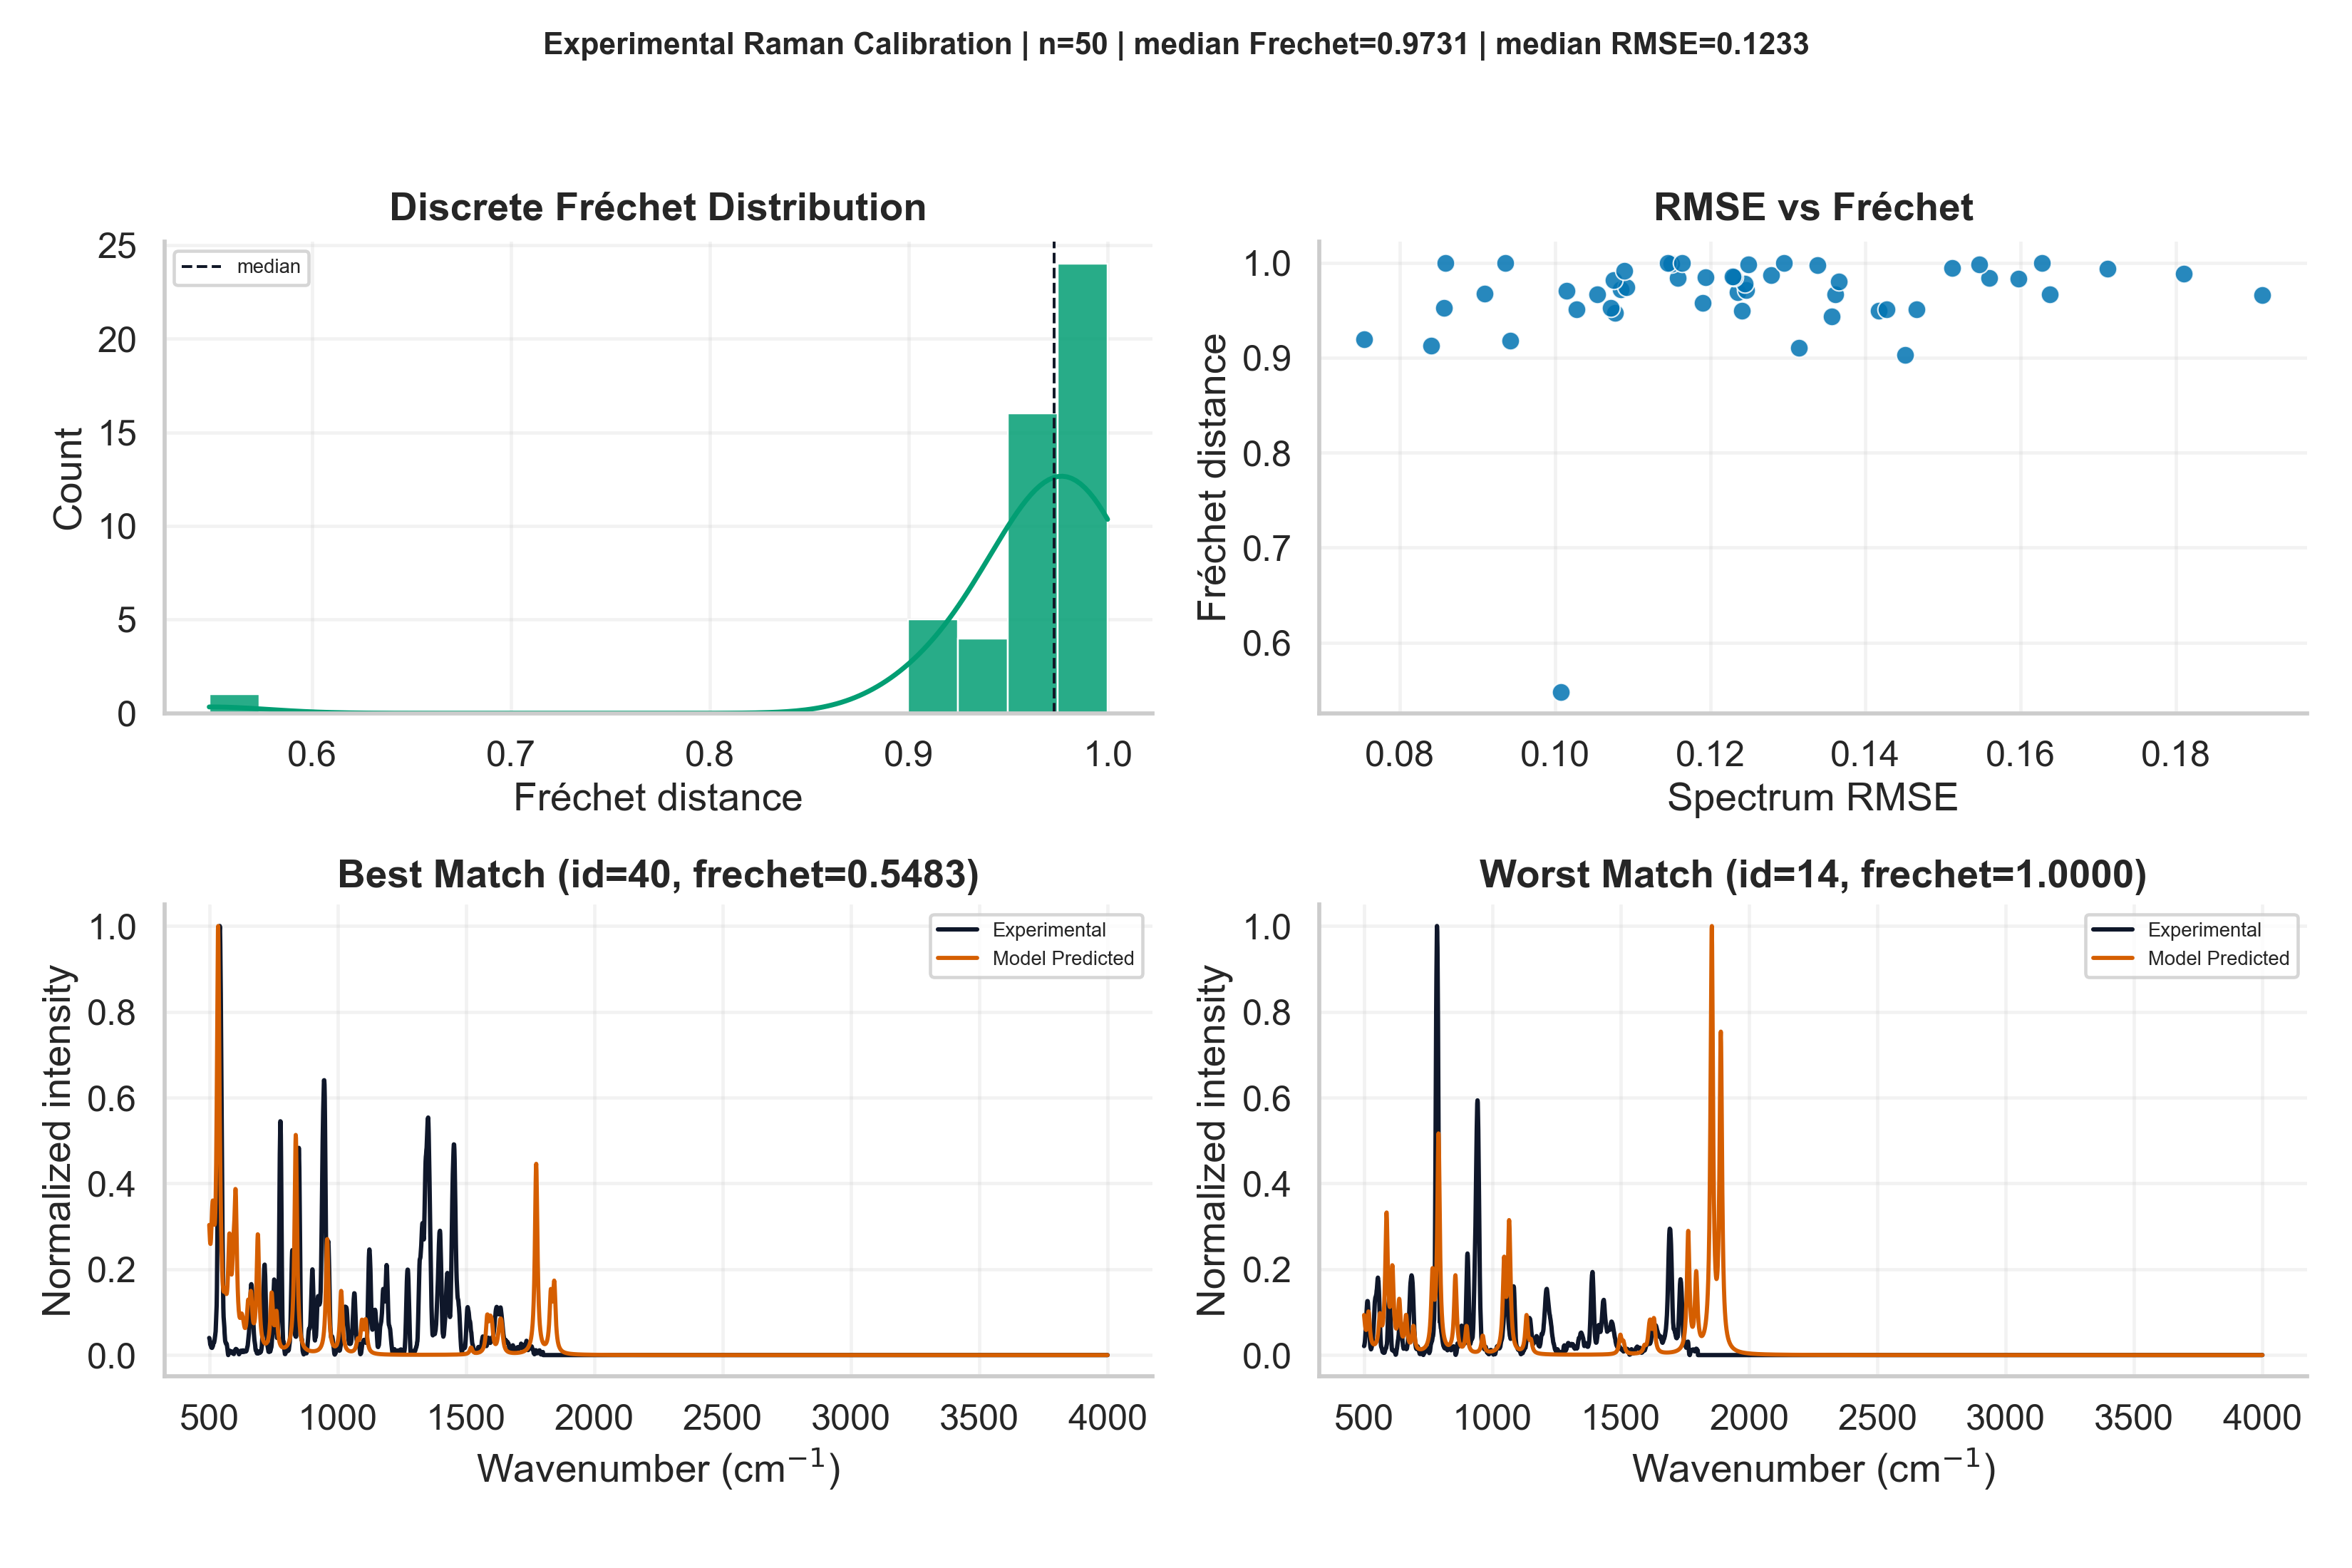

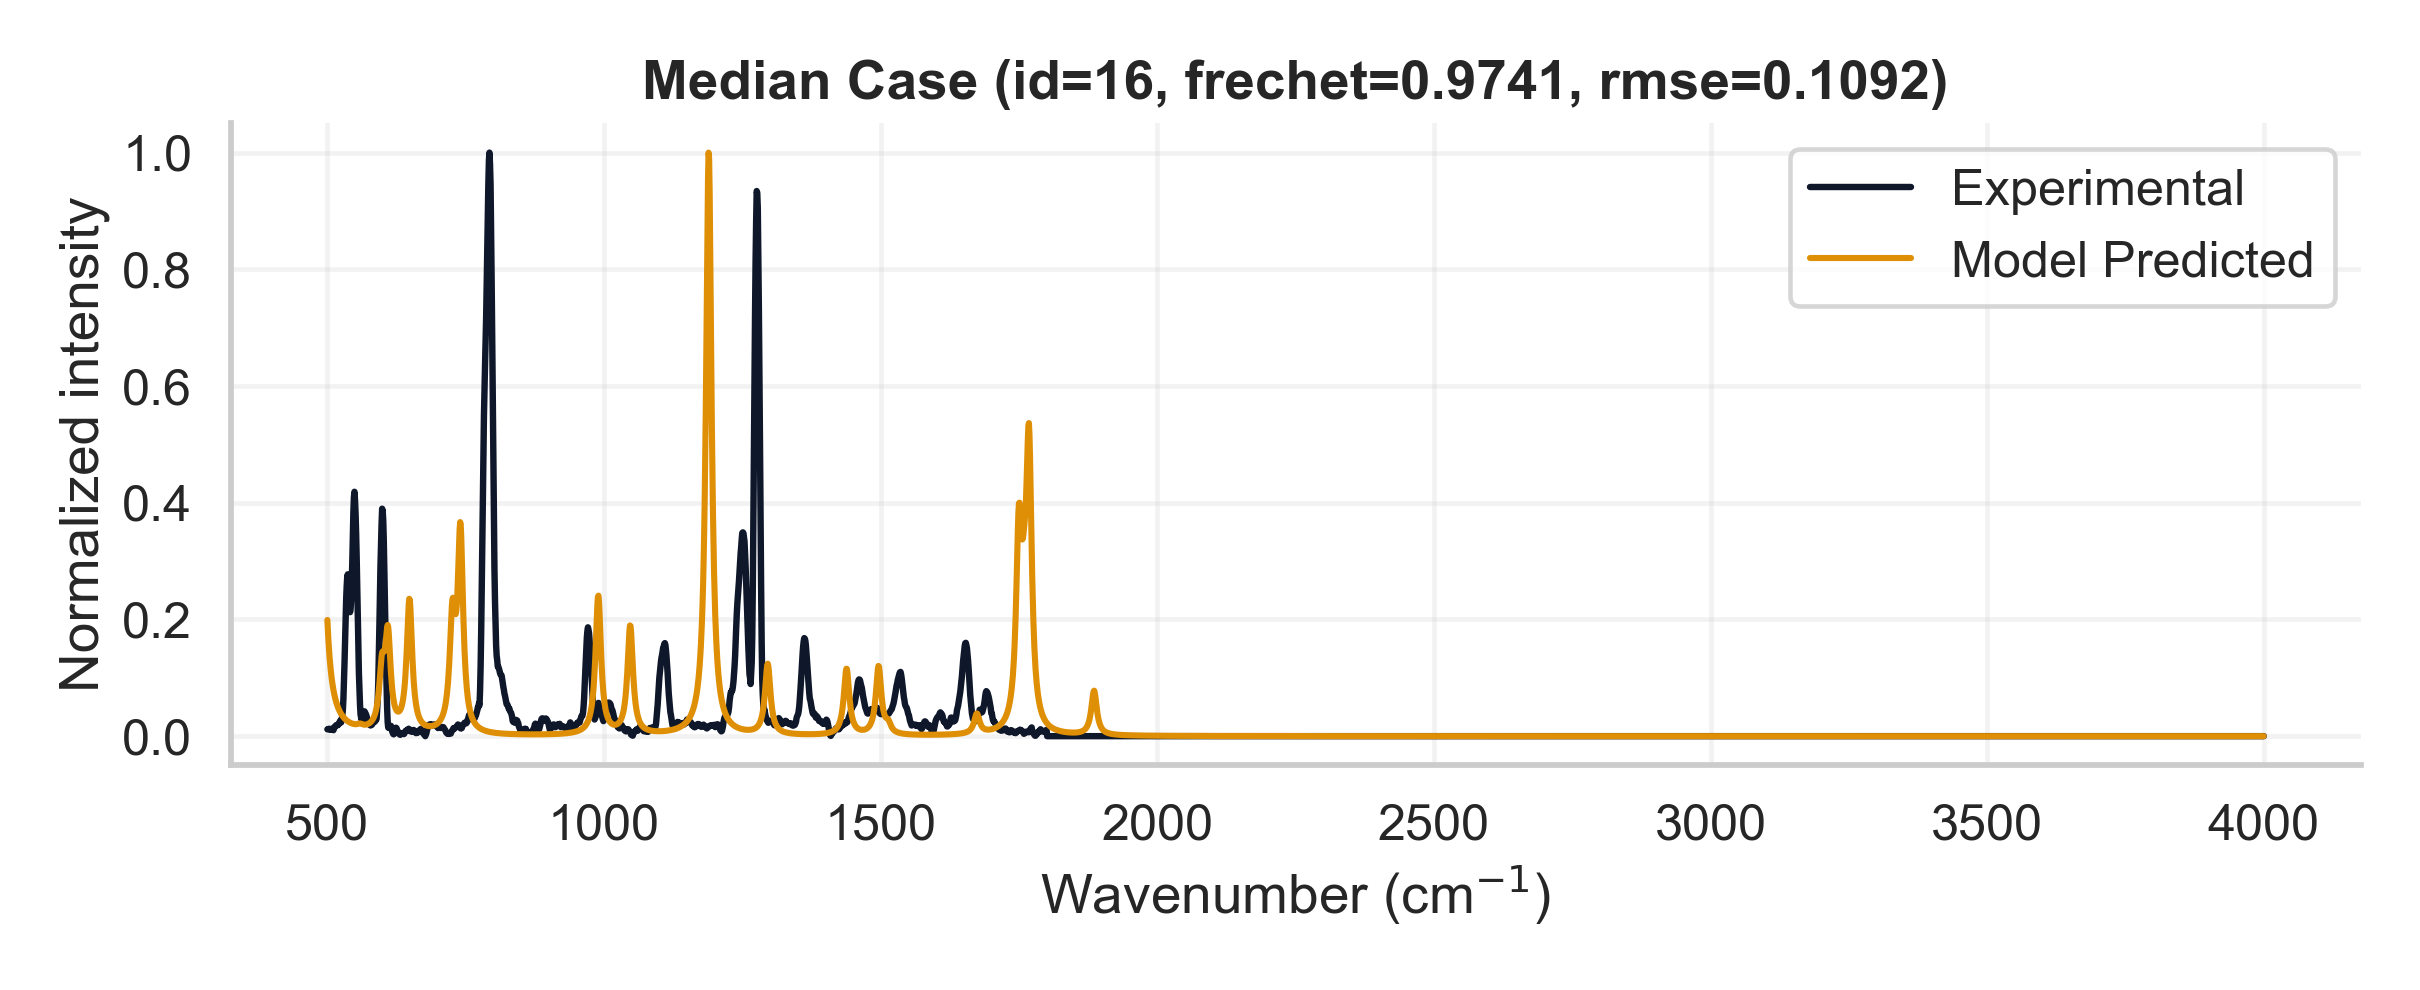

In [9]:
# Build plots (same analysis layout as depolar_spectra_pipeline)
plot_main = OUT_DIR / "experimental_calibration_frechet_plot.png"
plot_median = OUT_DIR / "experimental_calibration_median_overlay.png"

case_by_id = {int(c["row_id"]): c for c in cases}
best = case_by_id[int(metrics_df.iloc[0]["row_id"])]
worst = case_by_id[int(metrics_df.iloc[-1]["row_id"])]
med = case_by_id[int(metrics_df.iloc[len(metrics_df) // 2]["row_id"])]

sns.set_theme(style="whitegrid", context="talk")
palette = sns.color_palette("colorblind")
COL = {
    "hist": palette[2],
    "scatter": palette[0],
    "exp": "#0f172a",
    "pred": palette[3],
    "pred_med": palette[1],
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=False)

sns.histplot(
    data=metrics_df,
    x="frechet",
    bins=min(18, max(6, len(metrics_df) // 2)),
    kde=True,
    color=COL["hist"],
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8,
    ax=axes[0, 0],
)
axes[0, 0].axvline(metrics_df["frechet"].median(), color="#111827", ls="--", lw=1.3, label="median")
axes[0, 0].set_title("Discrete Fréchet Distribution", pad=10, weight="semibold")
axes[0, 0].set_xlabel("Fréchet distance")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend(frameon=True, fontsize=9)

sns.scatterplot(
    data=metrics_df,
    x="rmse",
    y="frechet",
    s=70,
    alpha=0.85,
    color=COL["scatter"],
    edgecolor="white",
    linewidth=0.7,
    ax=axes[0, 1],
)
axes[0, 1].set_title("RMSE vs Fréchet", pad=10, weight="semibold")
axes[0, 1].set_xlabel("Spectrum RMSE")
axes[0, 1].set_ylabel("Fréchet distance")

for ax, case, title in (
    (axes[1, 0], best, "Best Match"),
    (axes[1, 1], worst, "Worst Match"),
):
    x = case["x_grid"]
    sns.lineplot(x=x, y=case["spec_exp"], lw=2.0, label="Experimental", color=COL["exp"], ax=ax)
    sns.lineplot(x=x, y=case["spec_pred"], lw=1.9, label="Model Predicted", color=COL["pred"], ax=ax)
    ax.set_title(f"{title} (id={case['row_id']}, frechet={case['frechet']:.4f})", pad=8, weight="semibold")
    ax.set_xlabel("Wavenumber (cm$^{-1}$)")
    ax.set_ylabel("Normalized intensity")
    ax.legend(loc="upper right", fontsize=9, frameon=True)

for ax in axes.ravel():
    ax.grid(True, alpha=0.25)
    sns.despine(ax=ax)

fig.suptitle(
    f"Experimental Raman Calibration | n={len(metrics_df)} | median Frechet={metrics_df['frechet'].median():.4f} | "
    f"median RMSE={metrics_df['rmse'].median():.4f}",
    fontsize=14,
    weight="bold",
    y=0.98,
)
fig.tight_layout(rect=[0.0, 0.02, 1.0, 0.95])
fig.savefig(plot_main, dpi=220, facecolor="white")
plt.close(fig)

fig2, ax2 = plt.subplots(figsize=(11, 4.5))
sns.lineplot(x=med["x_grid"], y=med["spec_exp"], lw=2.1, label="Experimental", color=COL["exp"], ax=ax2)
sns.lineplot(x=med["x_grid"], y=med["spec_pred"], lw=2.0, label="Model Predicted", color=COL["pred_med"], ax=ax2)
ax2.set_title(
    f"Median Case (id={med['row_id']}, frechet={med['frechet']:.4f}, rmse={med['rmse']:.4f})",
    pad=8,
    weight="semibold",
)
ax2.set_xlabel("Wavenumber (cm$^{-1}$)")
ax2.set_ylabel("Normalized intensity")
ax2.grid(True, alpha=0.25)
ax2.legend(loc="upper right", frameon=True)
sns.despine(ax=ax2)
fig2.tight_layout()
fig2.savefig(plot_median, dpi=220, facecolor="white")
plt.close(fig2)

print("plot_main  =", plot_main)
print("plot_median=", plot_median)

print("Top 8 (best Fréchet):")
display(metrics_df.head(8))
print("Bottom 8 (worst Fréchet):")
display(metrics_df.tail(8))

display(Image(filename=str(plot_main)))
display(Image(filename=str(plot_median)))



stats_cases = 50


/Users/rahul/Desktop/hp-proteins-ml/.venv/lib/python3.13/site-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/Users/rahul/Desktop/hp-proteins-ml/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)



=== Peak Statistical Summary ===
{
  "tolerances": {
    "median_abs_dnu_cm_max": 10.0,
    "p90_abs_dnu_cm_max": 20.0,
    "hit15_min": 0.85,
    "any_neighbor_at_10_min": 0.8,
    "mae_log10_ratio_max": 0.2
  },
  "equivalence_bounds": {
    "position_mean_dnu_cm": [
      -12.0,
      12.0
    ],
    "intensity_mean_log10_ratio": [
      -0.2,
      0.2
    ],
    "alpha": 0.05
  },
  "settings": {
    "freq_scale_factor": 0.967,
    "peak_match_window_cm": 10.0,
    "peak_prominence_frac": 0.03,
    "peak_min_distance_cm": 8.0,
    "stat_max_molecules": 50
  },
  "aggregate_metrics": {
    "matched_peak_count": 105,
    "molecule_count": 50,
    "median_abs_dnu_cm": 5.0,
    "p90_abs_dnu_cm": 9.0,
    "hit15": 1.0,
    "any_neighbor_at_10": 0.20917669516993811,
    "mae_log10_ratio": 0.41745710633717337,
    "frechet_median": 0.9730777143966806,
    "frechet_mean": 0.9620137787346218
  },
  "bootstrap_ci": {
    "median_abs_dnu_cm_ci95": [
      NaN,
      NaN
    ],
    "hit15_ci

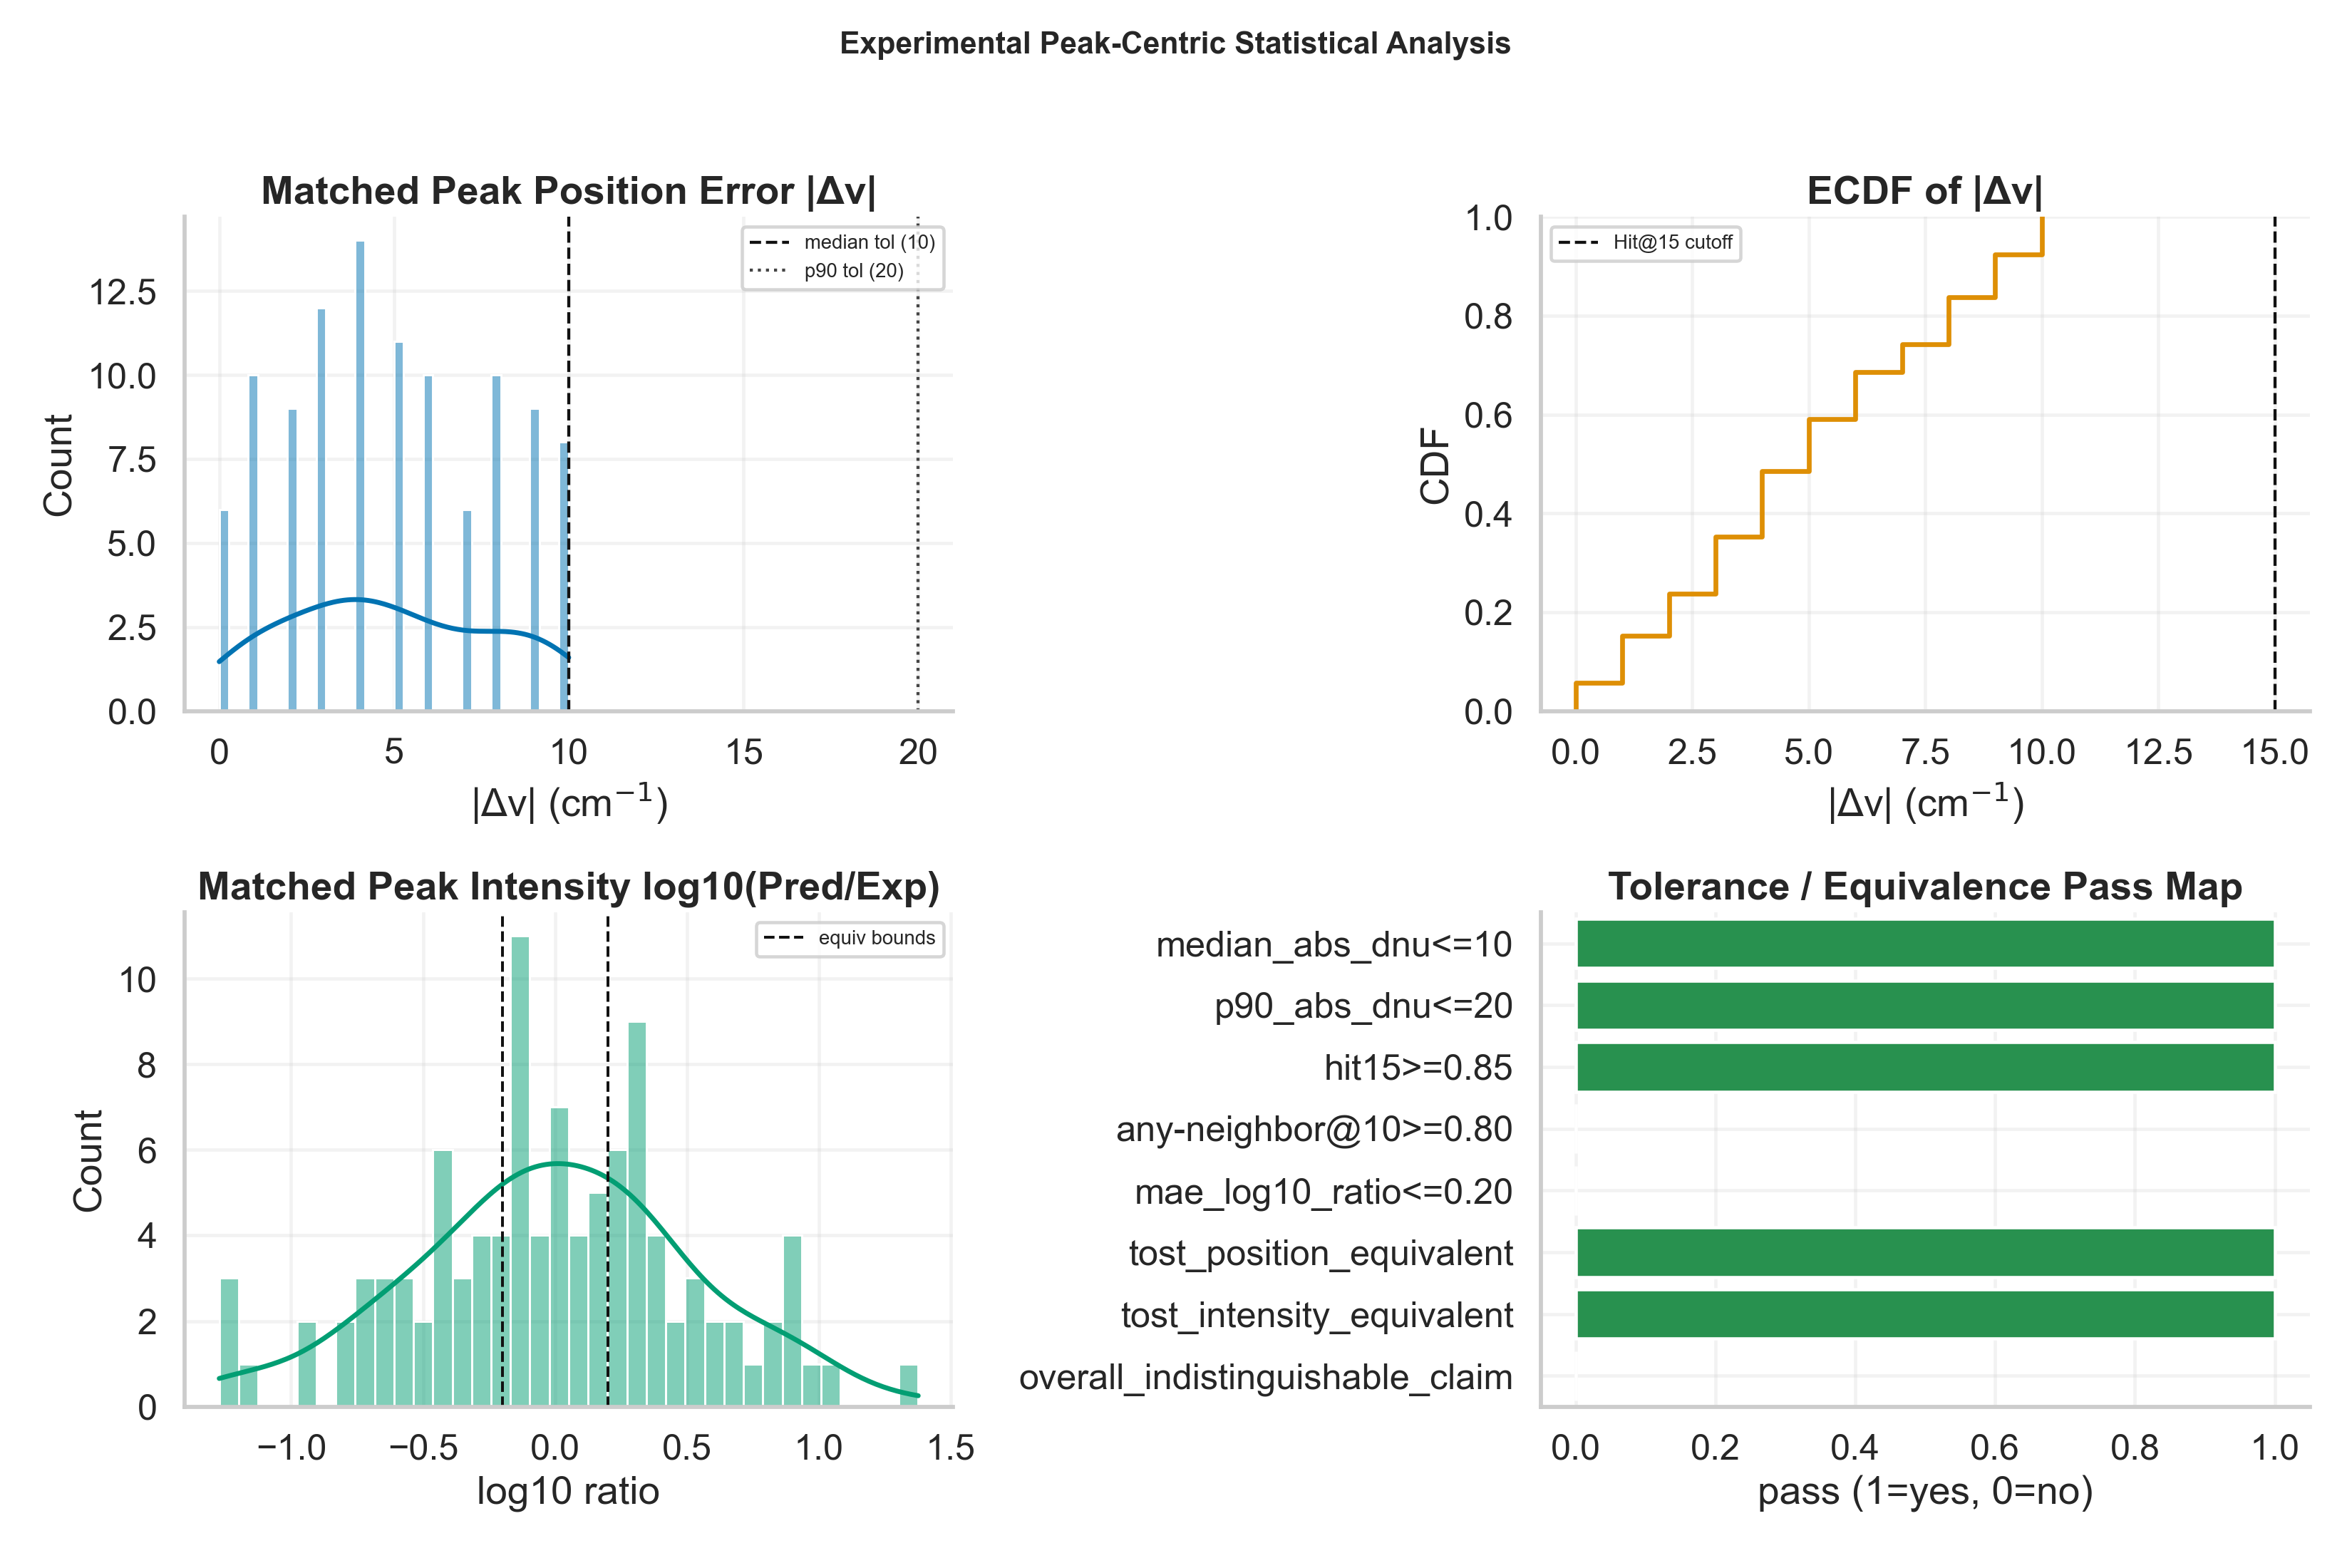

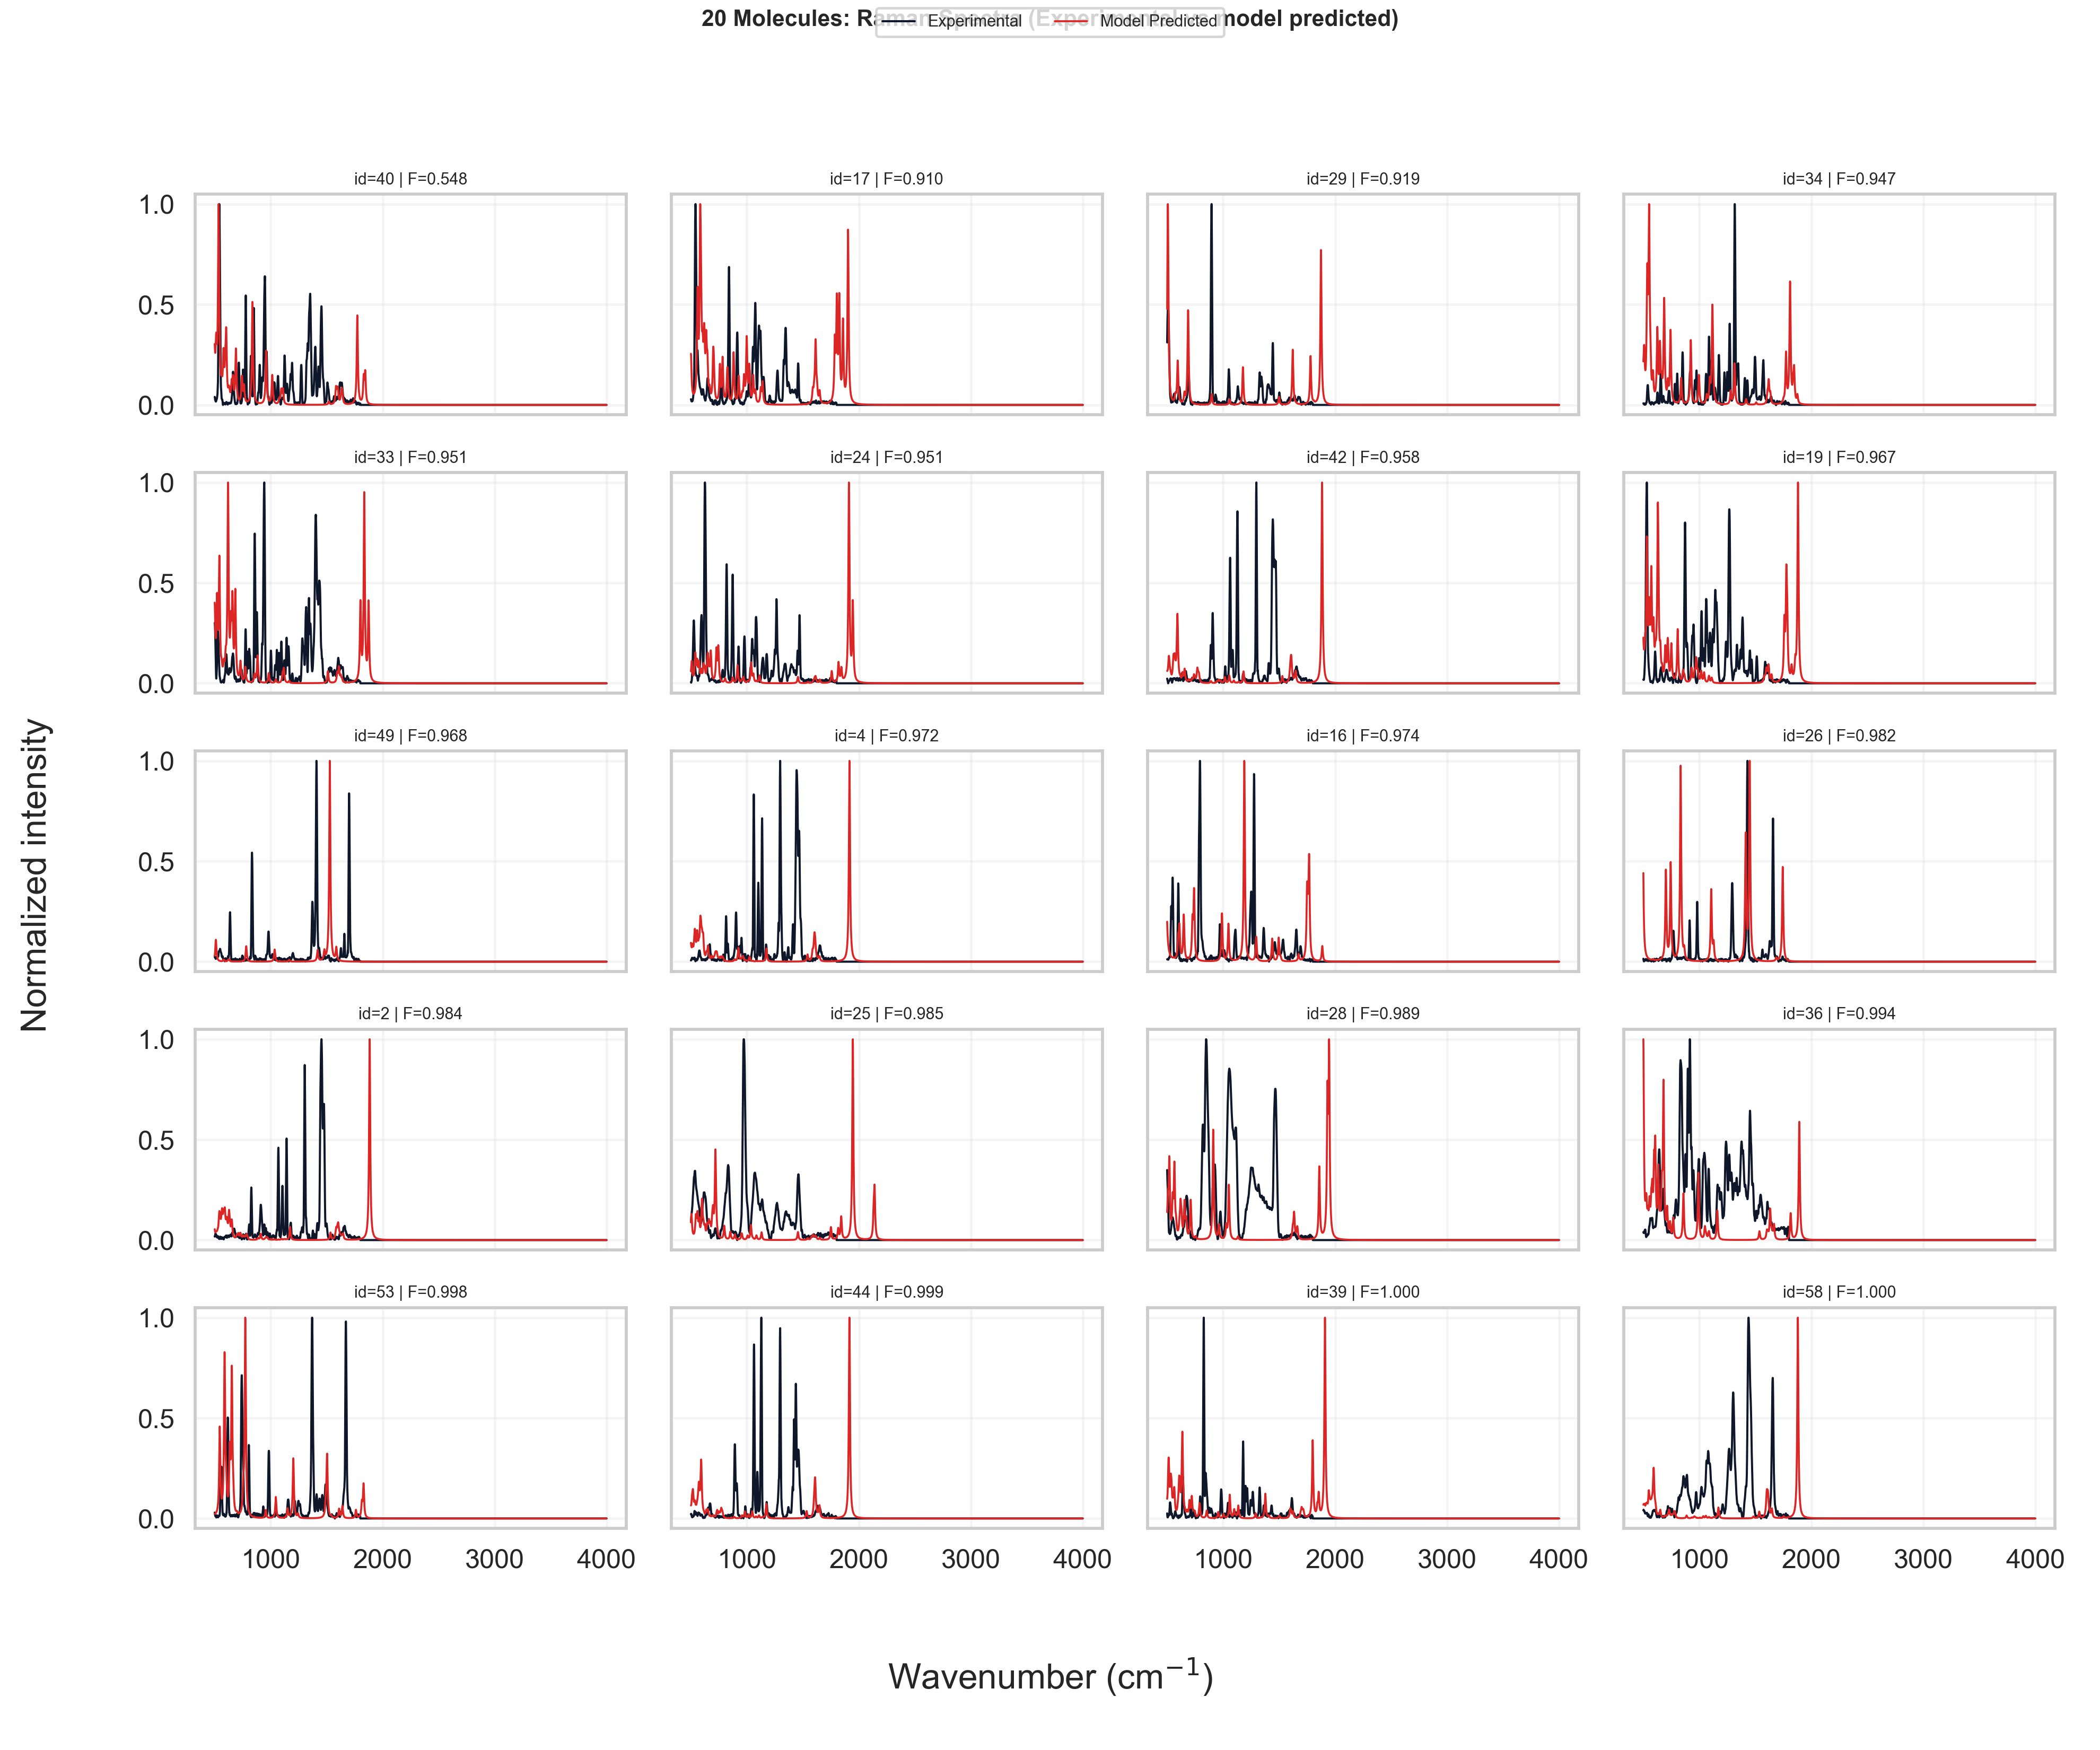

In [10]:
# Peak statistical test (same framework as depolar_spectra_pipeline)
from scipy.signal import find_peaks
from scipy.optimize import linear_sum_assignment
from scipy.stats import bootstrap
from statsmodels.stats.weightstats import ttost_paired

# -----------------------------
# Statistical knobs
# -----------------------------
STAT_MAX_MOLECULES = 50

PEAK_PROMINENCE_FRAC = 0.03
PEAK_MIN_DISTANCE_CM = 8.0
PEAK_MATCH_WINDOW_CM = 10.0

# Acceptance thresholds
TOL_MEDIAN_ABS_DNU = 10.0
TOL_P90_ABS_DNU = 20.0
TOL_HIT15 = 0.85
TOL_ANY_NEIGHBOR_10 = 0.80
TOL_MAE_LOG10_RATIO = 0.20

# Equivalence bounds (TOST)
EQ_DNU_LOW, EQ_DNU_HIGH = -12.0, 12.0
EQ_LOGR_LOW, EQ_LOGR_HIGH = -0.20, 0.20
ALPHA = 0.05


def _extract_peaks(x_grid, y, prominence_frac=0.03, min_distance_cm=8.0):
    y = np.asarray(y, dtype=np.float64)
    x_grid = np.asarray(x_grid, dtype=np.float64)
    if y.size < 3 or np.nanmax(y) <= 0:
        return np.array([]), np.array([])

    dx = float(np.median(np.diff(x_grid)))
    min_distance_pts = max(1, int(round(min_distance_cm / max(dx, 1e-12))))
    prominence = float(prominence_frac * np.nanmax(y))

    idx, _ = find_peaks(y, prominence=prominence, distance=min_distance_pts)
    if idx.size == 0:
        return np.array([]), np.array([])

    return x_grid[idx], y[idx]


def _match_peaks(dft_freq, dft_int, pred_freq, pred_int, max_window_cm=30.0):
    dft_freq = np.asarray(dft_freq, dtype=np.float64)
    dft_int = np.asarray(dft_int, dtype=np.float64)
    pred_freq = np.asarray(pred_freq, dtype=np.float64)
    pred_int = np.asarray(pred_int, dtype=np.float64)

    n_dft = dft_freq.size
    n_pred = pred_freq.size

    if n_dft == 0:
        return {
            'matched_dft_freq': np.array([]),
            'matched_pred_freq': np.array([]),
            'matched_dft_int': np.array([]),
            'matched_pred_int': np.array([]),
            'n_dft': 0,
            'n_pred': int(n_pred),
            'n_matched': 0,
            'n_unmatched_dft': 0,
            'n_unmatched_pred': int(n_pred),
        }

    if n_pred == 0:
        return {
            'matched_dft_freq': np.array([]),
            'matched_pred_freq': np.array([]),
            'matched_dft_int': np.array([]),
            'matched_pred_int': np.array([]),
            'n_dft': int(n_dft),
            'n_pred': 0,
            'n_matched': 0,
            'n_unmatched_dft': int(n_dft),
            'n_unmatched_pred': 0,
        }

    cost = np.abs(dft_freq[:, None] - pred_freq[None, :])
    row_ind, col_ind = linear_sum_assignment(cost)
    keep = cost[row_ind, col_ind] <= float(max_window_cm)

    r = row_ind[keep]
    c = col_ind[keep]

    return {
        'matched_dft_freq': dft_freq[r],
        'matched_pred_freq': pred_freq[c],
        'matched_dft_int': dft_int[r],
        'matched_pred_int': pred_int[c],
        'n_dft': int(n_dft),
        'n_pred': int(n_pred),
        'n_matched': int(keep.sum()),
        'n_unmatched_dft': int(n_dft - keep.sum()),
        'n_unmatched_pred': int(n_pred - keep.sum()),
    }


def _any_neighbor_rate(dft_freq, pred_freq, max_window_cm=10.0):
    dft_freq = np.asarray(dft_freq, dtype=np.float64)
    pred_freq = np.asarray(pred_freq, dtype=np.float64)
    if dft_freq.size == 0:
        return np.nan
    if pred_freq.size == 0:
        return 0.0
    dist = np.abs(dft_freq[:, None] - pred_freq[None, :])
    nearest = dist.min(axis=1)
    return float(np.mean(nearest <= float(max_window_cm)))


if not cases:
    raise RuntimeError('No evaluated cases available for peak statistics.')

stats_cases = list(cases)[: int(STAT_MAX_MOLECULES)]
print('stats_cases =', len(stats_cases))

# Peak extraction + matching per molecule
mol_rows = []
all_abs_dnu = []
all_signed_dnu = []
all_log_ratio = []
all_abs_log_ratio = []

for c in stats_cases:
    dft_f, dft_i = _extract_peaks(X_GRID, c['spec_exp'], prominence_frac=PEAK_PROMINENCE_FRAC, min_distance_cm=PEAK_MIN_DISTANCE_CM)
    pred_f, pred_i = _extract_peaks(X_GRID, c['spec_pred'], prominence_frac=PEAK_PROMINENCE_FRAC, min_distance_cm=PEAK_MIN_DISTANCE_CM)

    m = _match_peaks(dft_f, dft_i, pred_f, pred_i, max_window_cm=PEAK_MATCH_WINDOW_CM)
    any_neighbor_at_10 = _any_neighbor_rate(dft_f, pred_f, max_window_cm=PEAK_MATCH_WINDOW_CM)

    if m['n_matched'] > 0:
        signed_dnu = m['matched_pred_freq'] - m['matched_dft_freq']
        abs_dnu = np.abs(signed_dnu)
        log_ratio = np.log10((m['matched_pred_int'] + 1e-12) / (m['matched_dft_int'] + 1e-12))
        abs_log_ratio = np.abs(log_ratio)

        all_signed_dnu.append(signed_dnu)
        all_abs_dnu.append(abs_dnu)
        all_log_ratio.append(log_ratio)
        all_abs_log_ratio.append(abs_log_ratio)

        median_abs_dnu = float(np.median(abs_dnu))
        p90_abs_dnu = float(np.quantile(abs_dnu, 0.90))
        hit15 = float(np.mean(abs_dnu <= 15.0))
        mae_log_ratio = float(np.mean(abs_log_ratio))
        mean_signed_dnu = float(np.mean(signed_dnu))
        mean_log_ratio = float(np.mean(log_ratio))
    else:
        median_abs_dnu = np.nan
        p90_abs_dnu = np.nan
        hit15 = np.nan
        mae_log_ratio = np.nan
        mean_signed_dnu = np.nan
        mean_log_ratio = np.nan

    mol_rows.append({
        'row_id': c['row_id'],
        'component': c['component'],
        'n_dft_peaks': m['n_dft'],
        'n_pred_peaks': m['n_pred'],
        'n_matched': m['n_matched'],
        'any_neighbor_at_10': any_neighbor_at_10,
        'median_abs_dnu_cm': median_abs_dnu,
        'p90_abs_dnu_cm': p90_abs_dnu,
        'hit15': hit15,
        'mae_log10_ratio': mae_log_ratio,
        'mean_signed_dnu_cm': mean_signed_dnu,
        'mean_log10_ratio': mean_log_ratio,
        'frechet': c['frechet'],
        'rmse': c['rmse'],
    })

peak_mol_df = pd.DataFrame(mol_rows)
peak_mol_df = peak_mol_df.sort_values(['median_abs_dnu_cm', 'any_neighbor_at_10'], ascending=[True, False], na_position='last').reset_index(drop=True)

if len(all_abs_dnu) == 0:
    raise RuntimeError('No matched peaks found in statistical subset. Relax peak params.')

signed_dnu_all = np.concatenate(all_signed_dnu)
abs_dnu_all = np.concatenate(all_abs_dnu)
log_ratio_all = np.concatenate(all_log_ratio)
abs_log_ratio_all = np.concatenate(all_abs_log_ratio)

# Equivalence tests (TOST) using per-molecule means
mol_signed = peak_mol_df['mean_signed_dnu_cm'].dropna().to_numpy(dtype=np.float64)
mol_logr = peak_mol_df['mean_log10_ratio'].dropna().to_numpy(dtype=np.float64)

p_tost_pos, tost_pos_low, tost_pos_high = ttost_paired(mol_signed, np.zeros_like(mol_signed), low=EQ_DNU_LOW, upp=EQ_DNU_HIGH)
p_tost_int, tost_int_low, tost_int_high = ttost_paired(mol_logr, np.zeros_like(mol_logr), low=EQ_LOGR_LOW, upp=EQ_LOGR_HIGH)

# Bootstrap CIs
boot_med_abs_dnu = bootstrap((abs_dnu_all,), np.median, confidence_level=0.95, n_resamples=10000, random_state=123)
boot_hit15 = bootstrap((abs_dnu_all <= 15.0,), np.mean, confidence_level=0.95, n_resamples=10000, random_state=123)

# Threshold pass/fail
agg = {
    'matched_peak_count': int(abs_dnu_all.size),
    'molecule_count': int(len(peak_mol_df)),
    'median_abs_dnu_cm': float(np.median(abs_dnu_all)),
    'p90_abs_dnu_cm': float(np.quantile(abs_dnu_all, 0.90)),
    'hit15': float(np.mean(abs_dnu_all <= 15.0)),
    'any_neighbor_at_10': float(peak_mol_df['any_neighbor_at_10'].dropna().mean()),
    'mae_log10_ratio': float(np.mean(abs_log_ratio_all)),
    'frechet_median': float(metrics_df['frechet'].median()),
    'frechet_mean': float(metrics_df['frechet'].mean()),
}

passes = {
    'median_abs_dnu<=10': bool(agg['median_abs_dnu_cm'] <= TOL_MEDIAN_ABS_DNU),
    'p90_abs_dnu<=20': bool(agg['p90_abs_dnu_cm'] <= TOL_P90_ABS_DNU),
    'hit15>=0.85': bool(agg['hit15'] >= TOL_HIT15),
    'any-neighbor@10>=0.80': bool(agg['any_neighbor_at_10'] >= TOL_ANY_NEIGHBOR_10),
    'mae_log10_ratio<=0.20': bool(agg['mae_log10_ratio'] <= TOL_MAE_LOG10_RATIO),
    'tost_position_equivalent': bool(p_tost_pos < ALPHA),
    'tost_intensity_equivalent': bool(p_tost_int < ALPHA),
}
passes['overall_indistinguishable_claim'] = bool(
    passes['median_abs_dnu<=10']
    and passes['p90_abs_dnu<=20']
    and passes['hit15>=0.85']
    and passes['any-neighbor@10>=0.80']
    and passes['mae_log10_ratio<=0.20']
    and passes['tost_position_equivalent']
    and passes['tost_intensity_equivalent']
)

summary = {
    'tolerances': {
        'median_abs_dnu_cm_max': TOL_MEDIAN_ABS_DNU,
        'p90_abs_dnu_cm_max': TOL_P90_ABS_DNU,
        'hit15_min': TOL_HIT15,
        'any_neighbor_at_10_min': TOL_ANY_NEIGHBOR_10,
        'mae_log10_ratio_max': TOL_MAE_LOG10_RATIO,
    },
    'equivalence_bounds': {
        'position_mean_dnu_cm': [EQ_DNU_LOW, EQ_DNU_HIGH],
        'intensity_mean_log10_ratio': [EQ_LOGR_LOW, EQ_LOGR_HIGH],
        'alpha': ALPHA,
    },
    'settings': {
        'freq_scale_factor': FREQ_SCALE_FACTOR,
        'peak_match_window_cm': PEAK_MATCH_WINDOW_CM,
        'peak_prominence_frac': PEAK_PROMINENCE_FRAC,
        'peak_min_distance_cm': PEAK_MIN_DISTANCE_CM,
        'stat_max_molecules': STAT_MAX_MOLECULES,
    },
    'aggregate_metrics': agg,
    'bootstrap_ci': {
        'median_abs_dnu_cm_ci95': [
            float(boot_med_abs_dnu.confidence_interval.low),
            float(boot_med_abs_dnu.confidence_interval.high),
        ],
        'hit15_ci95': [
            float(boot_hit15.confidence_interval.low),
            float(boot_hit15.confidence_interval.high),
        ],
    },
    'tost': {
        'position_pvalue': float(p_tost_pos),
        'position_low_test': {'t': float(tost_pos_low[0]), 'p': float(tost_pos_low[1]), 'df': float(tost_pos_low[2])},
        'position_high_test': {'t': float(tost_pos_high[0]), 'p': float(tost_pos_high[1]), 'df': float(tost_pos_high[2])},
        'intensity_pvalue': float(p_tost_int),
        'intensity_low_test': {'t': float(tost_int_low[0]), 'p': float(tost_int_low[1]), 'df': float(tost_int_low[2])},
        'intensity_high_test': {'t': float(tost_int_high[0]), 'p': float(tost_int_high[1]), 'df': float(tost_int_high[2])},
    },
    'passes': passes,
}

# Persist
peak_metrics_csv = OUT_DIR / 'experimental_peak_metrics_per_molecule.csv'
peak_summary_json = OUT_DIR / 'experimental_peak_statistical_summary.json'
stats_dist_plot = OUT_DIR / 'experimental_peak_statistical_analysis.png'
overlay20_plot = OUT_DIR / 'experimental_spectra_20_pred_vs_exp.png'

peak_mol_df.to_csv(peak_metrics_csv, index=False)
peak_summary_json.write_text(json.dumps(summary, indent=2))

# Distribution plot
sns.set_theme(style='whitegrid', context='talk')
palette = sns.color_palette('colorblind')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(abs_dnu_all, bins=36, kde=True, color=palette[0], ax=axes[0, 0])
axes[0, 0].axvline(TOL_MEDIAN_ABS_DNU, color='#111111', ls='--', lw=1.4, label='median tol (10)')
axes[0, 0].axvline(TOL_P90_ABS_DNU, color='#444444', ls=':', lw=1.4, label='p90 tol (20)')
axes[0, 0].set_title('Matched Peak Position Error |Δν|', weight='semibold')
axes[0, 0].set_xlabel('|Δν| (cm$^{-1}$)')
axes[0, 0].legend(fontsize=9)

sns.ecdfplot(abs_dnu_all, color=palette[1], lw=2.2, ax=axes[0, 1])
axes[0, 1].axvline(15.0, color='#111111', ls='--', lw=1.4, label='Hit@15 cutoff')
axes[0, 1].set_title('ECDF of |Δν|', weight='semibold')
axes[0, 1].set_xlabel('|Δν| (cm$^{-1}$)')
axes[0, 1].set_ylabel('CDF')
axes[0, 1].legend(fontsize=9)

sns.histplot(log_ratio_all, bins=36, kde=True, color=palette[2], ax=axes[1, 0])
axes[1, 0].axvline(EQ_LOGR_LOW, color='#111111', ls='--', lw=1.3, label='equiv bounds')
axes[1, 0].axvline(EQ_LOGR_HIGH, color='#111111', ls='--', lw=1.3)
axes[1, 0].set_title('Matched Peak Intensity log10(Pred/Exp)', weight='semibold')
axes[1, 0].set_xlabel('log10 ratio')
axes[1, 0].legend(fontsize=9)

pass_df = pd.DataFrame({'criterion': list(passes.keys()), 'pass': [int(v) for v in passes.values()]})
pass_df['status'] = pass_df['pass'].map({1: 'pass', 0: 'fail'})
sns.barplot(
    data=pass_df,
    x='pass',
    y='criterion',
    hue='status',
    orient='h',
    dodge=False,
    palette={'pass': '#16a34a', 'fail': '#dc2626'},
    legend=False,
    ax=axes[1, 1],
)
axes[1, 1].set_xlim(-0.05, 1.05)
axes[1, 1].set_title('Tolerance / Equivalence Pass Map', weight='semibold')
axes[1, 1].set_xlabel('pass (1=yes, 0=no)')
axes[1, 1].set_ylabel('')

for ax in axes.ravel():
    ax.grid(True, alpha=0.25)
    sns.despine(ax=ax)

fig.suptitle('Experimental Peak-Centric Statistical Analysis', fontsize=14, weight='bold', y=0.98)
fig.tight_layout(rect=[0, 0.01, 1, 0.96])
fig.savefig(stats_dist_plot, dpi=220, facecolor='white')
plt.close(fig)

# 20-case overlay plot (Experimental vs model predicted)
ranked_cases = sorted(stats_cases, key=lambda x: x['frechet'])
n_select = min(20, len(ranked_cases))
sel_idx = np.linspace(0, len(ranked_cases) - 1, num=n_select, dtype=int)
selected = [ranked_cases[i] for i in sel_idx]

ncols = 4
nrows = int(np.ceil(n_select / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.0 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, c in zip(axes, selected):
    ax.plot(X_GRID, c['spec_exp'], color='#0f172a', lw=1.3, label='Experimental')
    ax.plot(X_GRID, c['spec_pred'], color='#dc2626', lw=1.2, label='Model Predicted')
    ax.set_title(f"id={c['row_id']} | F={c['frechet']:.3f}", fontsize=10)
    ax.grid(True, alpha=0.2)

for ax in axes[n_select:]:
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes[:n_select]:
    lg = ax.get_legend()
    if lg is not None:
        lg.remove()

fig.legend(handles, labels, loc='upper center', ncol=2, frameon=True, fontsize=10)
fig.suptitle('20 Molecules: Raman Spectra (Experimental vs model predicted)', fontsize=14, weight='bold', y=0.995)
fig.supxlabel('Wavenumber (cm$^{-1}$)', y=0.03)
fig.supylabel('Normalized intensity', x=0.01)
fig.tight_layout(rect=[0.02, 0.04, 1.0, 0.95])
fig.savefig(overlay20_plot, dpi=220, facecolor='white')
plt.close(fig)

print()
print('=== Peak Statistical Summary ===')
print(json.dumps(summary, indent=2))
print('peak_metrics_csv =', peak_metrics_csv)
print('peak_summary_json=', peak_summary_json)
print('stats_dist_plot  =', stats_dist_plot)
print('overlay20_plot   =', overlay20_plot)

display(Image(filename=str(stats_dist_plot)))
display(Image(filename=str(overlay20_plot)))


In [11]:
# Exact subset of compounds tested (for reproducibility)

# 1) Main evaluated subset used in calibration metrics
subset_eval = (
    metrics_df[["row_id", "component", "query_name", "cid", "n_atoms", "n_modes_pred", "frechet", "rmse", "corr"]]
    .copy()
    .sort_values("row_id")
    .reset_index(drop=True)
)
subset_eval_csv = OUT_DIR / "tested_compounds_eval_subset.csv"
subset_eval.to_csv(subset_eval_csv, index=False)

print("evaluated_subset_count =", len(subset_eval))
print("evaluated_subset_csv   =", subset_eval_csv)
display(subset_eval)

# 2) Peak-stats subset (may be identical to evaluated subset, depending on caps)
if "stats_cases" in globals():
    subset_stats = pd.DataFrame(
        [
            {
                "row_id": int(c["row_id"]),
                "component": c["component"],
                "frechet": float(c["frechet"]),
                "rmse": float(c["rmse"]),
            }
            for c in stats_cases
        ]
    ).sort_values("row_id").reset_index(drop=True)

    subset_stats_csv = OUT_DIR / "tested_compounds_peak_stats_subset.csv"
    subset_stats.to_csv(subset_stats_csv, index=False)

    print("peak_stats_subset_count =", len(subset_stats))
    print("peak_stats_subset_csv   =", subset_stats_csv)
    display(subset_stats)



evaluated_subset_count = 24
evaluated_subset_csv   = /Users/rahul/Desktop/hp-proteins-ml/ramanchembl_pipeline/artifacts/calibration/tested_compounds_eval_subset.csv


,row_id,component,query_name,cid,n_atoms,n_modes_pred,frechet,rmse,corr
0,1,12-methyltetradecanoic acid,12-methyltetradecanoic acid,21672,47,135,0.986767,0.127816,-0.029296
1,2,13-methylmyristicacid,13-methylmyristic acid,151014,47,135,0.983944,0.115802,-0.026866
2,3,14-methylhexadecanoic acid,14-methylhexadecanoic acid,22207,53,151,0.977707,0.124487,-0.036899
3,4,14-methylpentadecanoic acid,14-methylpentadecanoic acid,36247,50,143,0.971509,0.124654,-0.030648
4,5,15-methylpalmiticacid,15-methylpalmitic acid,164860,53,152,0.985443,0.122926,-0.029883
5,6,acetoacetate,acetoacetate,6971017,12,30,0.994540,0.151202,0.072643
6,8,adenine,adenine,190,15,36,0.912931,0.084032,0.193307
7,11,ascorbic acid,ascorbic acid,54670067,20,48,0.998526,0.154655,0.034673
8,14,citric acid,citric acid,311,21,51,1.000000,0.093559,0.215336
9,16,cytosine,cytosine,597,13,30,0.974102,0.109237,0.030530


## Calibration Summary (50-sample run)

### Run setup
- Evaluated rows: **50** (`MAX_EVAL_ROWS = 50`)
- Peak-stats subset: **50** (`STAT_MAX_MOLECULES = 50`)
- Frequency scaling used: **single-pass** `FREQ_SCALE_FACTOR = 0.967`
- Checkpoint selection (executed run):
  - `Hi`: `artifacts/hi/prod-hi-a10080x8-clean-20260224-182057/latest_Hi.pth`
  - `Hij`: `artifacts/hij/prod-hij-a10080x8-2ep-20260224-232300/latest_Hij.pth`

### Core calibration metrics
- Median Fréchet: **0.9731**
- Mean Fréchet: **0.9620**
- Median RMSE: **0.1233**
- Mean RMSE: **0.1247**

### Peak-statistical test (same framework as depolar notebook)
Aggregate metrics:
- `median_abs_dnu_cm = 5.0`
- `p90_abs_dnu_cm = 9.0`
- `hit15 = 1.0`
- `any_neighbor_at_10 = 0.209`
- `mae_log10_ratio = 0.417`

Pass map:
- ✅ `median_abs_dnu <= 10`
- ✅ `p90_abs_dnu <= 20`
- ✅ `hit15 >= 0.85`
- ❌ `any-neighbor@10 >= 0.80`
- ❌ `mae_log10_ratio <= 0.20`
- ✅ `tost_position_equivalent`
- ✅ `tost_intensity_equivalent`
- ❌ `overall_indistinguishable_claim`

### Interpretation
- **Peak positions are reasonably aligned** (strong position-error metrics and positive TOST on mean position/intensity).
- The main failures are **coverage and intensity-ratio quality**:
  - Low `any_neighbor_at_10` means many experimental peaks do not have a nearby predicted counterpart within 10 cm^-1.
  - High `mae_log10_ratio` means matched-peak amplitudes still differ substantially.
- So this run shows **partial agreement** (good central position error on matched peaks) but **not full indistinguishability** under the strict acceptance criteria.

